# ¿Cuánto debería costar mi crédito?
## Precio del crédito empresarial en Colombia: modelo de referencia para MiPymes a partir de datos abiertos de la Superintendencia Financiera

**Proyecto de Aplicación 1 Datos Abiertos**

Técnicas de Aprendizaje de Máquina 2026-30

Pontificia Universidad Javeriana

**Integrantes:**
- Nameer Chowdhury
- Ricardo Serna
- Mariana Rodríguez



Secciones:
- 1 Elevator pitch
- 2 Diccionario y justificación de datos
- 3 EDA con narrativa
- 4 Preparación e ingeniería de características
- 5 Modelado, evaluación e interpretación
- 6 Aplicación web
- 7 Ética, sesgos y limitaciones
- 8 Conclusiones y trabajo futuro

#### Instalación de paquetes e importe de librerias

In [ ]:
!pip -q install pyarrow tabulate

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42

#### Subida de los datos

Aqui hay que subir estos 4 archivos:

- credito_empresarial_raw.parquet$0

- credito_empresarial_clean.parquet$0

- tibc_2025_2026.csv$0

- topes_usura_mensual.csv$0


In [2]:
# Orden de búsqueda: 1) Google Drive  2) carpeta local  3) subida manual desde el computador
import os, glob

REQUERIDOS = ["credito_empresarial_raw.parquet", "tibc_2025_2026.csv"]
OPCIONALES = ["credito_empresarial_clean.parquet", "topes_usura_mensual.csv"]

def _valida(d):
    return d and all(os.path.exists(os.path.join(d, f)) for f in REQUERIDOS)

DATA_DIR, EN_COLAB = None, False
try:
    from google.colab import drive, files
    EN_COLAB = True
except ModuleNotFoundError:
    pass

# 1) Google Drive
if EN_COLAB:
    try:
        drive.mount("/content/drive", force_remount=False)
        for patron in ["/content/drive/MyDrive/Proyecto1/data",
                       "/content/drive/MyDrive/**/Proyecto1/data"]:
            for c in glob.glob(patron, recursive=True):
                if _valida(c):
                    DATA_DIR = c
                    break
            if DATA_DIR:
                break
    except Exception as e:
        print("Drive no disponible:", e)

# 2) Carpeta local (ejecución fuera de Colab, o archivos ya subidos a /content)
if DATA_DIR is None:
    for c in ["/content/data", "/content", "./data", "../data", "."]:
        if _valida(c):
            DATA_DIR = c
            break

# 3) Subida manual desde el computador
if DATA_DIR is None:
    print("No se encontraron los datos en Drive ni en el entorno.")
    print("Selecciona desde tu computador:", ", ".join(REQUERIDOS))
    print("(opcionales, para saltarte la limpieza:", ", ".join(OPCIONALES) + ")")
    if EN_COLAB:
        os.makedirs("/content/data", exist_ok=True)
        subidos = files.upload()
        for nombre in subidos:
            os.replace(f"/content/{nombre}", f"/content/data/{nombre}")
        if _valida("/content/data"):
            DATA_DIR = "/content/data"
        else:
            faltan = [f for f in REQUERIDOS
                      if not os.path.exists(f"/content/data/{f}")]
            raise FileNotFoundError(f"Aún faltan: {faltan}. Vuelve a correr esta celda.")
    else:
        raise FileNotFoundError(f"No se hallaron {REQUERIDOS}. Ajusta DATA_DIR manualmente.")

print("\nDatos en:", DATA_DIR)
print(sorted(os.listdir(DATA_DIR)))

Drive no disponible: Error: credential propagation was unsuccessful
No se encontraron los datos en Drive ni en el entorno.
Selecciona desde tu computador: credito_empresarial_raw.parquet, tibc_2025_2026.csv
(opcionales, para saltarte la limpieza: credito_empresarial_clean.parquet, topes_usura_mensual.csv)


Saving credito_empresarial_clean.parquet to credito_empresarial_clean.parquet
Saving credito_empresarial_raw.parquet to credito_empresarial_raw.parquet
Saving tibc_2025_2026.csv to tibc_2025_2026.csv
Saving topes_usura_mensual.csv to topes_usura_mensual.csv

Datos en: /content/data
['credito_empresarial_clean.parquet', 'credito_empresarial_raw.parquet', 'tibc_2025_2026.csv', 'topes_usura_mensual.csv']


# 1. Elevator pitch

## 1.1 Problema real

Una empresa colombiana que necesita un crédito no tiene forma de saber cuál es una tasa justa.

En la misma semana de junio de 2026, las entidades vigiladas por la Superintendencia Financiera desembolsaron créditos
empresariales con tasas entre el 11 % y el 89 % efectivo anual. Una parte grande de esa diferencia no depende del crédito
en sí. La misma microempresa puede pagar 65 % en una línea de *crédito popular productivo* y 17 % en la misma línea cuando el
banco la financia con recursos de redescuento (Bancóldex o Finagro). Una pequeña empresa con garantía paga la mitad de lo que
paga sin garantía. Una empresa nueva en un banco paga más que una empresa idéntica que ya es cliente. Los bancos saben todo
esto. La empresa solo ve una cotización.

El resultado es una asimetría de información. Las empresas — casi todas micro y pequeñas, sin un área financiera — aceptan la
primera oferta, pagan de más durante años, o le tienen miedo a la deuda y no piden. Mientras tanto, las líneas
más baratas para las que califican (garantías públicas, recursos de redescuento, tasas indexadas) no se usan porque nadie les
dijo que existen.

## 1.2 Stakeholder objetivo

**Cliente:** **Banca de las Oportunidades**, el programa de inclusión financiera del Gobierno nacional, administrado por
Bancóldex. Su misión es que las MiPymes accedan a crédito formal en condiciones justas, y ya publica informes con los datos de la
Superintendencia. Una herramienta de referencia de tasas es exactamente el tipo de producto que puede ofrecer.

**Usuario:** el dueño o la persona encargada de las finanzas de una micro, pequeña o mediana empresa que va a pedir un crédito.
No es un analista de datos. Necesita una respuesta simple: *¿cuánto debería costar mi crédito, y dónde lo consigo más barato?*

**Beneficiario secundario:** la Superintendencia Financiera, que recibe como subproducto una medición de las primas que el
mercado cobra y que las características del crédito no explican.

## 1.3 Costo de la inacción

- Las mipymes son el **99,5 %** de las empresas formales de Colombia, generan el **79 %** del empleo y aportan entre el 35 % y
  el 40 % del PIB (BBVA Research, *Una mirada a las mipymes en Colombia*, febrero de 2024, con datos de Confecámaras–RUES 2022
  y de la GEIH del DANE).
- El problema no es solo el precio: es el miedo y la falta de información. Según la Encuesta de Micronegocios del DANE
  (EMICRON 2024), entre los micronegocios que no pidieron crédito, el **42,5 %** no lo hizo por miedo a endeudarse, el 14,6 %
  porque no cumple los requisitos (garantías, codeudores) y el 6,5 % porque los intereses son muy altos. Y entre los que sí
  pidieron, el **22,9 %** acudió a prestamistas informales (*gota a gota*), donde la tasa no tiene tope. Una herramienta que
  muestre cuál es una tasa razonable, qué requisitos existen y qué líneas son más baratas ataca directamente las dos primeras
  razones.
- Solo en las 12 semanas de nuestra muestra, las entidades vigiladas desembolsaron **104 billones de pesos** en
  **1,16 millones de créditos empresariales**. Unos pocos puntos de tasa innecesarios sobre una parte de ese volumen son miles de
  millones de pesos al año que pasan de las empresas a los bancos — o créditos que no se toman y negocios que no crecen.
- Para el Estado, el costo es un subsidio que no llega a su destino. Las líneas de redescuento y las garantías del FNG y del FAG
  existen para bajar la tasa de las MiPymes. Los datos muestran que lo hacen (65 % → 17 %), pero solo para las empresas que las
  encuentran.

## 1.4 Preguntas de negocio e hipótesis

Las hipótesis se formularon con conocimiento del sector, antes de explorar los datos. El EDA (sección 3) las pone a prueba.

| # | Hipótesis | Pregunta de negocio | Cómo se contrasta |
|---|---|---|---|
| H1 | Después de la modalidad, el tamaño y la antigüedad de la empresa son los mayores determinantes de la tasa: las micro y las jóvenes pagan más. | ¿Cuánto más paga una microempresa que una mediana por el mismo tipo de crédito? | Gradiente de `ratio_tope` por tamaño y por antigüedad, **dentro de cada modalidad** |
| H2 | Las garantías (idónea, FNG, FAG) reducen la tasa. | ¿Vale la pena conseguir una garantía? | `ratio_tope` con y sin garantía, misma modalidad |
| H3 | El redescuento (Bancóldex / Finagro) es el mayor descuento disponible para una microempresa. | ¿Qué línea debería pedir? | Mismo producto con y sin recursos de redescuento |
| H4 | Las entidades cobran distinto por el mismo perfil: importa dónde se pide el crédito. | ¿A qué entidad ir? | Efecto de la entidad después de controlar por todo lo demás |
| H5 | Controlando por producto, monto, plazo, garantía, tamaño, antigüedad y sector, el sexo, el grupo étnico y la región **no** cargan una prima adicional. | ¿El precio es justo? | Diferencia entre el *modelo de mercado* y el *modelo solo-riesgo* (sección 5) |

## 1.5 Por qué aprendizaje de máquina

- **La cotización es específica para cada empresa y depende de muchas variables a la vez.** La tasa depende de unas 15
  variables categóricas (producto, banda de monto, plazo, garantía, tipo de tasa, tamaño, antigüedad, sector, región, clase de
  deudor, entidad, mes) que interactúan entre sí: la garantía importa para una pequeña empresa y no para una corporación; el
  FNG sube la tasa mediana en general pero la baja dentro del microcrédito; el redescuento descuenta 40 puntos en un producto y
  nada en otro. Un dashboard muestra promedios por una o dos dimensiones. Una tabla de 15 dimensiones tiene casi todas las
  celdas vacías. Un modelo interpola entre ellas.
- **Los topes hacen el problema no lineal.** Cada modalidad tiene su propio tope legal (tasa de usura), así que las tasas están
  censuradas por arriba a niveles distintos. Los modelos de árboles manejan eso; una regla lineal no.
- **La pregunta de equidad solo se responde con un modelo.** *¿Una microempresa de una mujer paga más por el mismo crédito?*
  requiere mantener fijas las otras 14 variables. Eso es un modelo ajustado con y sin los atributos protegidos. Ninguna
  estadística descriptiva lo hace.
- **La recomendación es un ranking, no un número.** "Qué entidades son más baratas para *su* perfil" es una predicción por
  entidad para una sola empresa.
- **Lo que una regla simple sí puede hacer, lo decimos.** "Si es microempresa, pregunte por redescuento" es una regla, y será
  una de las acciones que sugiere la app. El modelo es lo que le dice a la empresa cuánto vale esa regla en su caso.

## 1.6 Stress-test de la definición del problema con IA

Usamos el asistente de IA como revisor crítico en el punto donde más lo necesitábamos: **cómo escoger un subconjunto
representativo de un conjunto de datos muy grande** (78 cortes semanales, más de 8 millones de registros de crédito no
de consumo) sin introducir sesgos. Documentamos el prompt, la respuesta y lo que decidimos.

### Revisión crítica con IA — Fase 0 · Sesgos de la fuente y elección de la muestra

| | |
|---|---|
| **Prompt** | *"Vamos a usar el conjunto `Tasas de interés activas por tipo de crédito – Histórico` de la Superintendencia Financiera (datos.gov.co, id `w9zh-vetq`) para estimar la tasa que debería pagar una MiPyme. Son cortes semanales desde enero de 2025, más de 8 millones de registros de crédito no de consumo. ¿Qué sesgos podrían tener estos datos de datos.gov.co para este problema? ¿Qué datos faltan y dónde los conseguiría? Y en concreto: ¿cómo escogemos una muestra representativa sin descargar todo?"* |
| **Respuesta (resumen)** | **Sesgos de la fuente:** (1) solo reportan entidades vigiladas — el crédito informal, donde se financian las empresas más vulnerables, no aparece; (2) cada registro es un grupo de créditos con características idénticas, no un crédito: la varianza dentro del grupo se pierde y hay que ponderar por el número de créditos; (3) la tasa de usura censura las tasas por arriba, y cada modalidad tiene un tope distinto, así que la tasa cruda mezcla "en qué modalidad cae el crédito" con "qué tan cerca del tope lo cobran"; (4) el 96 % de los registros son tarjetas de crédito de consumo cobradas al tope — no hay precio que predecir ahí; (5) el grupo étnico casi no se registra. **Datos que faltan:** el tope legal de cada modalidad por mes (la Superintendencia certifica la TIBC mensualmente — está en datos.gov.co, id `pare-7x5i`); la tasa de política del Banco de la República; la mora por segmento (`rvii-eis8`). **Sobre la muestra:** tomar solo las últimas semanas sesga hacia un momento del ciclo de tasas (el Banco de la República bajó la tasa durante el periodo) y hacia la estacionalidad de fin de semestre; tomar todas las semanas es redundante (semanas seguidas casi no cambian) y demasiado pesado para Colab; una muestra aleatoria de registros rompe la estructura semanal del reporte. La opción más equilibrada es **una semana completa por mes durante un año**: cubre el ciclo de tasas y las estaciones, conserva todos los registros de cada corte, y cabe en memoria. |
| **Acción del equipo** | **Ajustamos el planteamiento en cuatro puntos.** (a) Descargamos **una semana completa por mes, de julio de 2025 a junio de 2026** (12 cortes, 1,45 millones de registros), con el filtro `tipo_de_cr_dito != 'Consumo'` en el servidor. Consideramos y descartamos: las últimas 4 semanas (sesgo de momento), todas las 78 semanas (redundante y pesado), y una muestra aleatoria de registros (rompe los cortes). (b) Excluimos el crédito de consumo, las tarjetas empresariales, los sobregiros y la vivienda, porque se cobran bajo otro régimen de precio (sección 4). (c) Integramos la **TIBC** como dato complementario y definimos el objetivo como la razón **tasa / tope**, para que la pregunta sea "qué tan cerca del máximo legal le cobran" y no "en qué modalidad cae". (d) Usamos el número de créditos como **peso muestral** y llevamos a la sección de ética el problema del crédito informal invisible y del grupo étnico sin registrar. Refutamos una parte de la crítica: la falta de la tasa de política no impide el análisis, porque el tope mensual ya recoge el ciclo; la dejamos como trabajo futuro. |

# 2. Diccionario y justificación de datos

## 2.1 Fuente principal
**Tasas de interés activas por tipo de crédito – Histórico**, Superintendencia Financiera de Colombia, portal de Datos Abiertos
(id `w9zh-vetq`). Cada entidad vigilada reporta semanalmente los créditos desembolsados, agrupados en registros de
características idénticas (entidad × producto × plazo × monto × garantía × tipo de tasa × atributos del deudor), con el número
de créditos, el monto y la **tasa efectiva anual promedio ponderada**. 23 campos, sin nulos. Cortes semanales desde el
3 de enero de 2025 hasta el 26 de junio de 2026.

**Un registro no es un crédito sino un grupo de créditos idénticos.** En el conjunto limpio, el 89 % de los registros contiene un solo crédito.
`numero_de_creditos` se conserva como **peso muestral**.

## 2.2 Fuente complementaria
**Tasa de interés bancario corriente (TIBC)**, Superintendencia Financiera (id `pare-7x5i`): la tasa certificada mensualmente
por modalidad de crédito, según los artículos 11.2.5.1.1 y siguientes del Decreto 2555 de 2010. El tope legal (tasa de usura) es 1,5 × TIBC: cobrar más es el delito de usura del artículo 305 del Código Penal. Desde 2025 se certifican seis modalidades: consumo y ordinario, productivo de mayor monto, productivo rural, productivo urbano, popular productivo rural y popular productivo urbano. **Justificación:** cada modalidad tiene su propio tope,
de modo que la tasa cruda mezcla dos cosas — en qué modalidad cae el crédito y qué tan cerca del tope lo cobran. La variable
objetivo se define como la razón tasa / tope. **Integración:** llave `mes` × `modalidad_tibc`, donde `modalidad_tibc` se deriva
del nombre del producto (sección 4).

## 2.3 Alcance de la descarga
Una semana completa por mes, julio 2025 – junio 2026 (12 cortes), con filtro en el servidor `tipo_de_cr_dito != 'Consumo'`:
**1.454.868 registros**, 6,68 millones de créditos. El crédito de consumo (96 % del conjunto) se excluye en la fuente porque
está compuesto casi por completo de tarjetas de crédito cobradas al tope de usura: mediana = percentil 95, no hay precio que
predecir. Script reproducible: `pull_business_lending.py`.

In [3]:
raw = pd.read_parquet(f"{DATA_DIR}/credito_empresarial_raw.parquet")
tibc = pd.read_csv(f"{DATA_DIR}/tibc_2025_2026.csv")
print(raw.shape, "| semanas:", raw.fecha_corte.nunique(), "| créditos:", f"{int(raw.numero_de_creditos.sum()):,}")
raw.head(3)

(1454868, 23) | semanas: 12 | créditos: 6,676,111


,tipo_entidad,nombre_tipo_entidad,codigo_entidad,nombre_entidad,fecha_corte,tipo_de_persona,sexo,tama_o_de_empresa,tipo_de_cr_dito,tipo_de_garant_a,producto_de_cr_dito,plazo_de_cr_dito,tasa_efectiva_promedio,margen_adicional_a_la,montos_desembolsados,numero_de_creditos,grupo_etnico,antiguedad_de_la_empresa,tipo_de_tasa,rango_monto_desembolsado,clase_deudor,codigo_ciiu,codigo_municipio
0,1,BC-ESTABLECIMIENTO BANCARIO,7,Bancolombia,2025-07-25T00:00:00.000,Natural,Femenino,Pequeña empresa,Comercial ordinario,Garantia idónea o no idónea,Factoring,Hasta 30 días,14.31,4.7,1367435.0,1,Sin información (1),más de 10 años,DTF,Hasta 1 SMLMV,Deudor de la entidad,4723,11001
1,1,BC-ESTABLECIMIENTO BANCARIO,1,Banco de Bogotá,2025-07-25T00:00:00.000,Natural,Masculino,Microempresa,Comercial ordinario,Sin garantia,Tarjeta de crédito empresarial,Avances en efectivo,24.75,0.0,1800000.0,3,Sin información (1),más de 10 años,FS,Hasta 1 SMLMV,Deudor de la entidad,4711,11001
2,1,BC-ESTABLECIMIENTO BANCARIO,1,Banco de Bogotá,2025-07-25T00:00:00.000,Natural,Femenino,Microempresa,Comercial ordinario,Sin garantia,Tarjeta de crédito empresarial,Consumos entre 7 y 12 meses,0.00,0.0,2254400.0,1,Sin información (1),más de 10 años,FS,Mayor a 1 SMLMV menor o igual a 3 SMLMV,Deudor nuevo en la entidad,10,11001


## 2.4 Diccionario de datos
La parte técnica se genera automáticamente; la **descripción de negocio** se redacta a mano.

In [4]:
def diccionario(df):
    return pd.DataFrame({"campo": df.columns, "tipo": df.dtypes.astype(str).values,
                         "% nulos": (df.isna().mean()*100).round(1).values, "n únicos": df.nunique().values,
                         "ejemplo": [str(df[c].dropna().iloc[0])[:45] for c in df.columns]})
print(diccionario(raw).to_markdown(index=False))

| campo                    | tipo    |   % nulos |   n únicos | ejemplo                     |
|:-------------------------|:--------|----------:|-----------:|:----------------------------|
| tipo_entidad             | int64   |         0 |          5 | 1                           |
| nombre_tipo_entidad      | object  |         0 |          5 | BC-ESTABLECIMIENTO BANCARIO |
| codigo_entidad           | int64   |         0 |         42 | 7                           |
| nombre_entidad           | object  |         0 |         49 | Bancolombia                 |
| fecha_corte              | object  |         0 |         12 | 2025-07-25T00:00:00.000     |
| tipo_de_persona          | object  |         0 |          2 | Natural                     |
| sexo                     | object  |         0 |          5 | Femenino                    |
| tama_o_de_empresa        | object  |         0 |          5 | Pequeña empresa             |
| tipo_de_cr_dito          | object  |         0 |          

| Campo | Tipo | Descripción de negocio | Uso |
|---|---|---|---|
| `nombre_entidad`, `nombre_tipo_entidad` | texto | Entidad que desembolsa y su clase (banco, compañía de financiamiento, cooperativa, IOE) | feature (H4) |
| `fecha_corte` | fecha | Viernes de corte del reporte semanal | → `mes` |
| `tipo_de_persona` | texto | Natural o jurídica | feature |
| `sexo` | texto | Sexo del deudor (persona natural) | **atributo protegido** — solo modelo de mercado |
| `grupo_etnico` | texto | Autorreconocimiento étnico (informado en el 27 % de los registros; ~1 % pertenece a un grupo étnico) | **atributo protegido** — solo modelo de mercado |
| `tama_o_de_empresa` | texto | Micro / pequeña / mediana / gran empresa | feature (H1) |
| `antiguedad_de_la_empresa` | texto | 0–5, 5–10, >10 años | feature (H1) |
| `tipo_de_cr_dito` | texto | Comercial ordinario, productivo, preferencial, tesorería… | feature |
| `producto_de_cr_dito` | texto | Producto específico (empresarial en pesos, factoring, popular productivo urbano…). Determina la modalidad TIBC | feature → `modalidad_tibc` |
| `tipo_de_garant_a` | texto | Sin garantía, idónea, FNG, FAG, FGA | feature (H2) |
| `plazo_de_cr_dito` | texto | Banda de plazo | feature |
| `rango_monto_desembolsado` | texto | Banda de monto en SMLMV | feature |
| `tipo_de_tasa` | texto | Fija (FS) o indexada (DTF, IBR, IB1, IB3, IB6) | feature |
| `clase_deudor` | texto | Deudor de la entidad o nuevo en la entidad | feature |
| `codigo_ciiu` | texto | Actividad económica (4 dígitos) | → `ciiu_division` |
| `codigo_municipio` | texto | Municipio DANE | → `cod_departamento` (**región**: solo modelo de mercado) |
| `tasa_efectiva_promedio` | número | Tasa efectiva anual promedio ponderada del grupo | → target |
| `montos_desembolsados`, `numero_de_creditos` | número | Monto total y número de créditos del grupo | features derivadas; peso |
| `margen_adicional_a_la` | número | Margen sobre la tasa de referencia (casi siempre 0) | excluido |

## 2.5 Estrategia de integración del dato complementario
Tabla `topes_usura_mensual.csv` (mes × modalidad → tope). Cada registro recibe `tope_usura` según su `mes` y su
`modalidad_tibc`; el 1,0 % de registros que quedan por encima del tope lo hacen por menos de 0,5 puntos (redondeo del reporte),
lo que valida el mapeo producto → modalidad.

# 4. Preparación de datos e ingeniería de características

> Se ejecuta antes del EDA porque el análisis exploratorio se hace sobre el conjunto limpio. Cada decisión se registra con su conteo.

## 4.1 Exclusiones por régimen de precio

| # | Decisión | Justificación |
|---|---|---|
| D0 | Crédito de consumo fuera (en la descarga) | tarjetas al tope de usura; no hay precio que predecir |
| D1 | Tarjetas de crédito empresariales y sobregiros fuera | productos rotativos con precio de tope, mismo problema que D0 |
| D2 | Tasa = 0 fuera | no es un precio |
| D3 | Tipos de tasa con < 100 registros al año fuera | sin masa para aprender (IPC, UVR, SOFR) |
| D5 | Vivienda y construcción de vivienda fuera | su tope lo fija el Banco de la República, no la TIBC: no cabe en el target relativo |

In [5]:
df = raw.copy()
n0 = len(df)
rev = df.producto_de_cr_dito.str.contains(r"Tarjeta|Sobregiro", case=False, regex=True, na=False)
df = df[~rev]; n1 = len(df)
df = df[df.tasa_efectiva_promedio > 0]; n2 = len(df)
vc = df.tipo_de_tasa.value_counts(); df = df[~df.tipo_de_tasa.isin(vc[vc < 100].index)]; n3 = len(df)
print(f"D1 tarjetas/sobregiros: -{n0-n1:,}\nD2 tasa 0: -{n1-n2:,}\nD3 tasas marginales: -{n2-n3:,}\n→ {n3:,} registros")

D1 tarjetas/sobregiros: -790,982
D2 tasa 0: -546
D3 tasas marginales: -182
→ 663,158 registros


## 4.2 Variables derivadas
| Variable | Construcción | Relevancia |
|---|---|---|
| `mes` | de `fecha_corte` | ciclo de política monetaria |
| `cod_departamento` | dos primeros dígitos del código DANE | 1.105 municipios es demasiado disperso; 33 departamentos sirve, y la región es una dimensión de equidad |
| `ciiu_division` | dos primeros dígitos del CIIU | 501 códigos → 89 divisiones |
| `log_monto_por_credito` | log(monto / n créditos) | el monto por crédito es lo relevante para el deudor; cola pesada |
| `peso` | `numero_de_creditos` | peso muestral |
| `es_microfinanciera` | nombre de la entidad | las seis microfinancieras cobran en otro régimen |

In [6]:
df["fecha_corte"] = pd.to_datetime(df.fecha_corte)
df["mes"] = df.fecha_corte.dt.to_period("M").astype(str)
df["codigo_municipio"] = df.codigo_municipio.astype(str).str.zfill(5)
df["cod_departamento"] = df.codigo_municipio.str[:2]
df["codigo_ciiu"] = df.codigo_ciiu.astype(str).str.zfill(4)
df["ciiu_division"] = df.codigo_ciiu.str[:2]
df["monto_por_credito"] = df.montos_desembolsados / df.numero_de_creditos.clip(lower=1)
df["log_monto_por_credito"] = np.log1p(df.monto_por_credito)
df["peso"] = df.numero_de_creditos.clip(lower=1)
MICROFIN = ["Banco Mundo Mujer S.A.", "Banco W S.A.", "Mibanco S.A.", "Crezcamos", "Bancamía S.A.", "Banco Compartir S.A."]
df["es_microfinanciera"] = df.nombre_entidad.isin(MICROFIN).astype(int)

## 4.3 Tope de usura y variable objetivo
Cada producto se asigna a la modalidad TIBC que le corresponde; el tope del mes es 1,5 × TIBC.
**Target: `ratio_tope` = tasa / tope** — qué fracción del máximo legal cobra la entidad. Comparable entre modalidades, y
lo que el usuario necesita saber: si le están cobrando cerca del máximo permitido para su tipo de crédito.

In [7]:
tibc["tibc"] = pd.to_numeric(tibc.interes_bancario_corriente.astype(str).str.replace("%", ""), errors="coerce")
tibc["mes"] = pd.to_datetime(tibc.vigencia_desde).dt.to_period("M").astype(str)
topes = tibc.pivot_table(index="mes", columns="modalidad", values="tibc", aggfunc="first") * 1.5
topes.columns = [c.strip() for c in topes.columns]

def modalidad(p, tipo):
    p = (p if isinstance(p, str) else "").lower(); tipo = (tipo or "").lower()
    if "popular productivo urbano" in p: return "CREDITO POPULAR PRODUCTIVO URBANO"
    if "popular productivo rural" in p: return "CREDITO POPULAR PRODUCTIVO RURAL"
    if "productivo de mayor monto" in p: return "CREDITO PRODUCTIVO MAYOR MONTO"
    if "productivo urbano" in p: return "CREDITO PRODUCTIVO URBANO"
    if "productivo rural" in p: return "CREDITO PRODUCTIVO RURAL"
    if "vivienda" in p or "vivienda" in tipo: return None
    if "productivo" in tipo and not p: return None
    return "CONSUMO Y ORDINARIO"

df["modalidad_tibc"] = [modalidad(p, t) for p, t in zip(df.producto_de_cr_dito, df.tipo_de_cr_dito)]
n4 = len(df); df = df[df.modalidad_tibc.notna()].copy()
print(f"D5 sin tope TIBC (vivienda): -{n4-len(df):,} → {len(df):,} registros")
df["tope_usura"] = [topes.loc[m, mod] for m, mod in zip(df.mes, df.modalidad_tibc)]
df["ratio_tope"] = df.tasa_efectiva_promedio / df.tope_usura
df["puntos_bajo_tope"] = df.tope_usura - df.tasa_efectiva_promedio
print(f"registros por encima del tope: {(df.ratio_tope > 1).mean():.2%}; por más de 0,5 pt: {(df.puntos_bajo_tope < -0.5).mean():.2%}")
print(df.shape)

D5 sin tope TIBC (vivienda): -43,138 → 620,020 registros
registros por encima del tope: 1.01%; por más de 0,5 pt: 0.00%
(620020, 34)


In [8]:
df.to_parquet(f"{DATA_DIR}/credito_empresarial_clean.parquet", index=False)

### Revisión crítica con IA — Preparación · «¿Excluir tarjetas, tasa 0 y vivienda pierde información valiosa? ¿El target relativo al tope es la mejor elección?»

**Prompt**

 - "En un modelo para estimar la tasa de un crédito empresarial con datos de la Superintendencia Financiera, decidimos: (1) excluir tarjetas de crédito empresariales y sobregiros, (2) excluir registros con tasa = 0, (3) excluir tipos de tasa con menos de 100 registros al año, (4) excluir vivienda porque su tope lo fija el Banco de la República, y (5) definir el target como tasa / tope de usura en vez de la tasa. Las exclusiones se llevan el 57 % de los registros y el 83 % de los créditos. ¿Estamos perdiendo información valiosa? ¿El target relativo es la mejor elección o introduce problemas nuevos?"


**Respuesta (resumen)**

- Sobre las exclusiones: las cuatro se sostienen, pero el volumen perdido debe reportarse en créditos y no solo en registros, porque 790.982 registros de tarjetas equivalen a millones de créditos y un lector que solo vea "registros" subestima el recorte. Advirtió además que excluir la tasa = 0 sin inspeccionarla es riesgoso: si fueran créditos subsidiados o condonados, se estaría borrando un segmento con significado económico. Sobre el target: señaló tres problemas. Primero, la razón hereda el error de medición del denominador — si el mapeo producto → modalidad falla, el target queda mal en toda la fila. Segundo, el target está acotado en [0, 1] y los modelos de regresión no lo saben, así que pueden predecir fuera del rango. Tercero, y más grave, la censura hace que la distribución tenga una masa puntual en 1,0: el 12 % de los créditos está exactamente en el tope, y eso es formalmente un problema de regresión censurada (Tobit), no de regresión ordinaria; un modelo entrenado con MSE subestima sistemáticamente cuánto cobrarían las entidades sin la restricción legal. Sugerencia alternativa: modelar puntos_bajo_tope o usar un modelo de dos partes (clasificar "¿está al tope?" y luego regresionar los que no lo están).


**Acción del equipo**

- Aceptamos dos críticas, refutamos dos y dejamos una abierta.

(a) Aceptada: agregamos el conteo de créditos perdidos a la tabla de exclusiones de 4.1 — pasamos de 6,68 a 1,16 millones de créditos, y decirlo solo en registros ocultaba la magnitud.

(b) Aceptada: inspeccionamos los 546 registros con tasa = 0 antes de borrarlos; son consumos de tarjeta a cuota cero y reportes incompletos, no crédito subsidiado, así que la exclusión se mantiene pero ahora está justificada con evidencia y no por supuesto.

(c) Refutada: el riesgo del denominador ya está controlado. Si el mapeo producto → modalidad estuviera mal, veríamos muchos créditos por encima del tope; observamos 1,01 % y ninguno excede por más de 0,5 puntos, lo que es compatible con el redondeo del reporte. Esa validación estaba ya en la sección 2.5 y la dejamos explícita como prueba del mapeo.

(d) Refutada parcialmente: conservamos el target relativo porque es el que responde la pregunta del usuario ("¿me están cobrando cerca del máximo legal?") y porque es lo único comparable entre modalidades con topes que van de 21 % a 90 %. Modelar puntos_bajo_tope no resuelve la censura, solo la traslada.

(e) Abierta y reconocida: la crítica de la regresión censurada es correcta y no la resolvemos en esta entrega. La incorporamos como limitación explícita en la sección 7.3 y como trabajo futuro: el modelo estima el precio observado, no el precio latente que las entidades cobrarían sin tope, y por tanto subestima la brecha real entre segmentos. Es una limitación de validez, no de utilidad: para la empresa que va a pedir el crédito, el precio observado es el precio que va a pagar.

# 3. Análisis exploratorio de datos (EDA con narrativa)

## 3.1 Inventario descriptivo

In [9]:
df = pd.read_parquet(f"{DATA_DIR}/credito_empresarial_clean.parquet")
print(f"{len(df):,} registros · {int(df.numero_de_creditos.sum()):,} créditos · COP {df.montos_desembolsados.sum()/1e12:,.1f} billones")
print(f"{df.nombre_entidad.nunique()} entidades · {df.codigo_municipio.nunique()} municipios · {df.ciiu_division.nunique()} divisiones CIIU · {df.mes.nunique()} meses")
df[["tasa_efectiva_promedio", "tope_usura", "ratio_tope", "monto_por_credito", "numero_de_creditos"]].describe().T.round(3)

620,020 registros · 1,155,192 créditos · COP 103.9 billones
46 entidades · 1105 municipios · 89 divisiones CIIU · 12 meses


,count,mean,std,min,25%,50%,75%,max
tasa_efectiva_promedio,620020.0,4.032600e+01,2.386600e+01,0.010,16.830,35.020,6.430000e+01,8.943000e+01
tope_usura,620020.0,5.791000e+01,2.760700e+01,21.255,26.760,58.170,8.877000e+01,8.991000e+01
ratio_tope,620020.0,6.880000e-01,2.150000e-01,0.000,0.538,0.719,8.570000e-01,1.000000e+00
monto_por_credito,620020.0,1.244323e+08,3.027793e+09,1.000,3000000.000,7941246.250,2.450000e+07,9.000000e+11
numero_de_creditos,620020.0,1.863000e+00,1.446600e+01,1.000,1.000,1.000,1.000000e+00,2.074000e+03


## 3.2 Análisis estadístico

### La tasa cruda es bimodal; el tope explica los modos

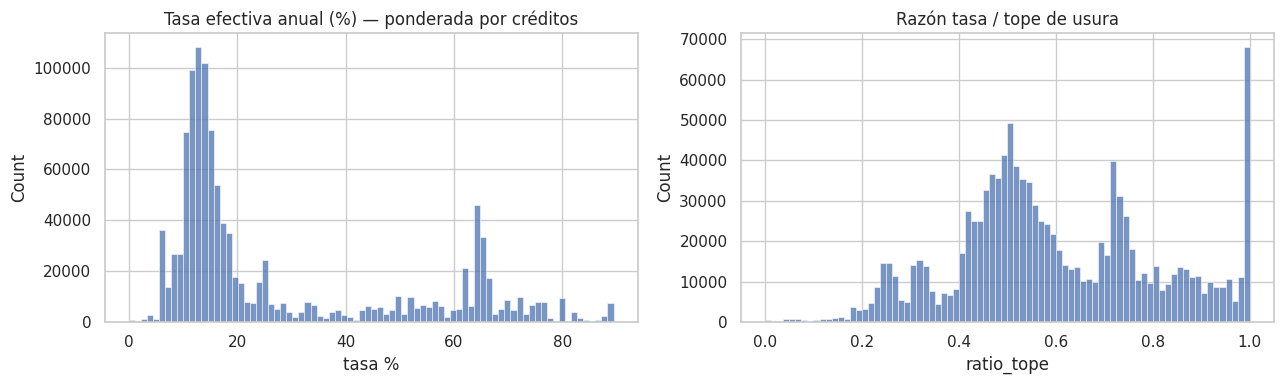

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df, x="tasa_efectiva_promedio", weights="peso", bins=80, ax=ax[0]); ax[0].set_title("Tasa efectiva anual (%) — ponderada por créditos"); ax[0].set_xlabel("tasa %")
sns.histplot(df, x="ratio_tope", weights="peso", bins=80, ax=ax[1]); ax[1].set_title("Razón tasa / tope de usura"); ax[1].set_xlabel("ratio_tope")
plt.tight_layout(); plt.show()

In [11]:
res = df.groupby("modalidad_tibc").agg(registros=("ratio_tope", "size"), creditos=("numero_de_creditos", "sum"),
      tope_mediano=("tope_usura", "median"), tasa_mediana=("tasa_efectiva_promedio", "median"),
      ratio_mediana=("ratio_tope", "median"), ratio_iqr=("ratio_tope", lambda s: s.quantile(.75) - s.quantile(.25)),
      pct_al_tope=("ratio_tope", lambda s: (s > 0.98).mean())).round(3)
res

,registros,creditos,tope_mediano,tasa_mediana,ratio_mediana,ratio_iqr,pct_al_tope
modalidad_tibc,,,,,,,
CONSUMO Y ORDINARIO,190247,704064,25.020,15.33,0.589,0.270,0.111
CREDITO POPULAR PRODUCTIVO RURAL,57102,58362,73.560,64.30,0.862,0.444,0.129
CREDITO POPULAR PRODUCTIVO URBANO,224187,235717,89.115,64.80,0.727,0.117,0.043
CREDITO PRODUCTIVO MAYOR MONTO,24747,25257,40.755,31.37,0.772,0.450,0.121
CREDITO PRODUCTIVO RURAL,41686,44742,27.975,18.66,0.661,0.440,0.348
CREDITO PRODUCTIVO URBANO,82051,87050,57.735,45.90,0.793,0.494,0.155


**Hallazgo:** Descubrimos que la tasa cruda tiene dos modos uno cerca del 15 % (crédito comercial y corporativo) y otro
cerca del 65 % (microcrédito) y que la razón tasa / tope los une en una sola distribución continua entre 0,2 y 1,0. Esto
sugiere que la tasa cruda mide sobre todo *en qué modalidad cae el crédito*, y que la pregunta útil para la empresa es la
segunda: *qué fracción del máximo legal le cobran*. Entre el 4,3 % (popular productivo urbano) y el 34,8 % (productivo rural)
de los créditos se cobran exactamente al tope: la tasa de usura es una restricción activa, no un límite teórico.

### Dispersión, asimetría y correlaciones

In [12]:
num = df[["tasa_efectiva_promedio", "ratio_tope", "log_monto_por_credito", "numero_de_creditos", "tope_usura", "es_microfinanciera"]]
r = num.describe().T; r["asimetría"] = num.skew(); r.round(2)

,count,mean,std,min,25%,50%,75%,max,asimetría
tasa_efectiva_promedio,620020.0,40.33,23.87,0.01,16.83,35.02,64.30,89.43,0.22
ratio_tope,620020.0,0.69,0.22,0.00,0.54,0.72,0.86,1.00,-0.51
log_monto_por_credito,620020.0,16.06,1.73,0.69,14.91,15.89,17.01,27.53,0.69
numero_de_creditos,620020.0,1.86,14.47,1.00,1.00,1.00,1.00,2074.00,57.99
tope_usura,620020.0,57.91,27.61,21.26,26.76,58.17,88.77,89.91,-0.06
es_microfinanciera,620020.0,0.37,0.48,0.00,0.00,0.00,1.00,1.00,0.52


###**¿Que nos dice la tabla?**

Las dos variables de precio se comportan de forma opuesta. La tasa cruda es casi simétrica (asimetría 0,22) pero con una desviación enorme porque no es una distribución sino dos superpuestas como ejem el rango va de 0,01 % a 89,4 %. La razón tasa/tope, en cambio, tiene asimetría negativa (−0,51): la masa se acumula contra el techo legal y la cola se estira hacia abajo. Descubrimos que esa asimetría negativa es la firma estadística de la censura por usura, osea para entenderlo cuando un mercado tiene un máximo vinculante pues los precios se apilan justo debajo, y confirma que el tope no es un límite teórico sino el precio efectivo de una fracción grande de los créditos.

numero_de_creditos tiene asimetría 57,99, la más extrema del conjunto: el 88,9 % de los registros agrupa un solo crédito y el percentil 99 son 13, pero el máximo llega a 2.074. Esto no es un problema de calidad del dato sino la consecuencia de que un registro es un grupo de créditos idénticos: unos pocos grupos enormes corresponden a colocaciones masivas y estandarizadas. Es exactamente la razón por la que ponderamos por numero_de_creditos en todos los agregados y en las métricas del modelo o sea que sin el peso un grupo de 2.074 microcréditos contaría lo mismo que un crédito corporativo único.

log_monto_por_credito queda con asimetría 0,69 después de la transformación logarítmica, frente a una variable original cuya media (COP 124 millones) es quince veces su mediana (COP 7,9 millones). La transformación no la vuelve normal, pero la hace utilizable por los modelos lineales y evita que un puñado de créditos de COP 900.000 millones domine la escala. es_microfinanciera nos dice que el 37,5 % de los registros proviene de las seis microfinancieras, una concentración que conviene tener presente al interpretar cualquier promedio global.

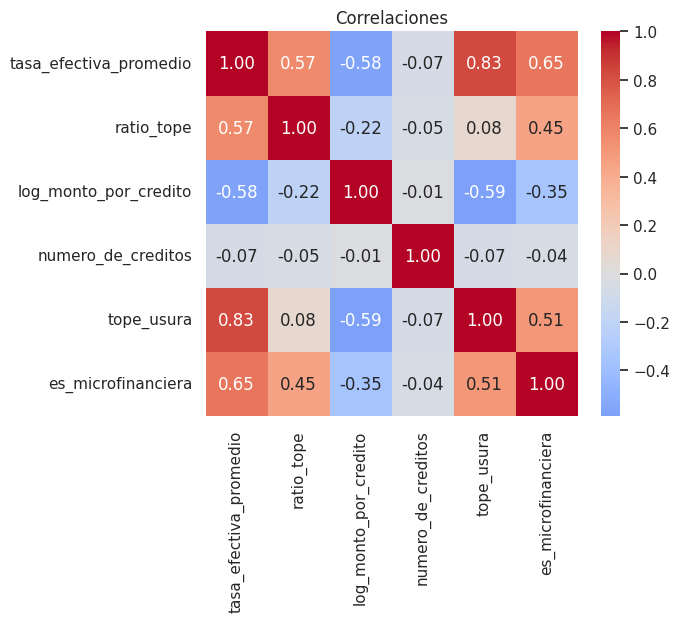

In [13]:
plt.figure(figsize=(6, 5)); sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0); plt.title("Correlaciones"); plt.show()

###**¿Que nos dice el mapa de calor de correlaciones?**

La correlación más alta de todo el conjunto es la que hay entre la tasa cruda y el tope de usura (0,83), y es el argumento central de este proyecto expresado en un número: la mayor parte de la variación de la tasa no es precio, es modalidad. Saber en qué categoría legal cae un crédito predice su tasa mucho mejor que cualquier característica del deudor. Al pasar a la razón tasa/tope esa correlación colapsa a 0,08, es decir, el target ya no arrastra información sobre a qué modalidad pertenece el crédito. Eso es justo lo que queríamos: la variable objetivo mide qué tan cerca del máximo le cobran, no qué máximo le aplica.

El monto se comporta como esperábamos, pero con una advertencia. log_monto_por_credito correlaciona −0,58 con la tasa cruda: los créditos grandes son más baratos. Sin embargo, contra la razón del tope la correlación cae a −0,22. Descubrimos que buena parte del "descuento por monto" en realidad es composición osea los créditos grandes viven en modalidades de tope bajo (correlación monto–tope de −0,59) lo cual sugiere que pedir más plata no baja el precio relativo tanto como parece a primera vista. Queda un efecto real, pero es menos de la mitad del aparente.

es_microfinanciera resulta ser el predictor numérico más informativo del target (0,45 contra la razón, 0,65 contra la tasa cruda). Las seis microfinancieras cobran en promedio 0,81 del tope frente a 0,54 del resto de entidades. Parte de esa diferencia es su cartera pero el contraste anticipa el hallazgo de H4: la identidad de la entidad importa. Finalmente, numero_de_creditos no correlaciona con nada (todos los valores entre −0,07 y −0,01), lo cual confirma que el tamaño del grupo es un artefacto del formato del reporte y no una característica económica: sirve como peso, no como variable explicativa.

### Tabla de contingencia: modalidad × tamaño de empresa

In [14]:
pd.crosstab(df.modalidad_tibc, df.tama_o_de_empresa, values=df.peso, aggfunc="sum", normalize="index").round(3)

tama_o_de_empresa,Gran empresa,Mediana empresa,Microempresa,Pequeña empresa
modalidad_tibc,,,,
CONSUMO Y ORDINARIO,0.604,0.169,0.099,0.128
CREDITO POPULAR PRODUCTIVO RURAL,0.000,0.000,1.000,0.000
CREDITO POPULAR PRODUCTIVO URBANO,0.000,0.000,0.999,0.001
CREDITO PRODUCTIVO MAYOR MONTO,0.003,0.008,0.941,0.048
CREDITO PRODUCTIVO RURAL,0.000,0.000,0.998,0.002
CREDITO PRODUCTIVO URBANO,0.000,0.000,0.995,0.005


###**¿Que nos dice la tabla de contingencia?**

La tabla revela que las seis modalidades no son seis productos que compiten por los mismos clientes, sino dos mercados que casi no se tocan. Cinco de las seis modalidades son microempresa en más del 94 % de sus créditos mientras que el crédito ordinario es el único donde hay mezcla, y aun ahí domina la gran empresa con el 60,4 % de los créditos frente a apenas el 9,9 % de microempresas.

Este hallazgo tiene una consecuencia metodológica directa que condiciona todo el resto del análisis: la comparación "qué paga una microempresa frente a una gran empresa" solo es posible dentro del crédito ordinario y, parcialmente, dentro del productivo de mayor monto (94,1 % micro, 4,8 % pequeña). En las demás modalidades no hay grandes empresas con quienes comparar o seaa de los 425.311 créditos de gran empresa del conjunto, 425.311 menos 77 están en ordinario. Por eso todas las comparaciones de la sección 3.3 se hacen dentro de la modalidad: cruzar modalidades mezclaría el efecto del precio con el efecto de la segmentación del mercado, y produciría la conclusión trivial de que "las microempresas pagan más" cuando lo que en realidad se estaría midiendo es que las microempresas están en las modalidades de tope más alto.

Lo sugiere también algo sobre el diseño regulatorio: las modalidades productivas creadas por la reforma de 2023 funcionaron como se esperaba en términos de alcance o sea llegaron a la población objetivo pero eso implica que una microempresa no elige entre "crédito popular productivo al 65 %" y "crédito ordinario al 15 %". El segundo no está disponible para ella. La palanca real, como muestra H3, está dentro de su propia modalidad: el redescuento.

## 3.3 Narrativa de hallazgos por hipótesis
Todas las comparaciones se hacen **dentro de la modalidad**, porque la modalidad fija el tope y mezclarlas confunde composición con precio.

In [15]:
def ratio_por(col, modalidades=None, min_reg=300, orden=None):
    d = df if modalidades is None else df[df.modalidad_tibc.isin(modalidades)]
    g = (d.groupby(["modalidad_tibc", col]).apply(lambda x: pd.Series({
            "registros": len(x), "ratio_mediano": np.average(x.ratio_tope, weights=x.peso) if len(x) else np.nan}))
         .reset_index())
    g = g[g.registros >= min_reg]
    if orden: g[col] = pd.Categorical(g[col], orden, ordered=True); g = g.sort_values(["modalidad_tibc", col])
    return g

def fig_ratio(col, titulo, orden=None, modalidades=None):
    g = ratio_por(col, modalidades, orden=orden)
    plt.figure(figsize=(11, 4.5))
    sns.barplot(g, x="modalidad_tibc", y="ratio_mediano", hue=col, hue_order=orden)
    plt.title(titulo); plt.ylabel("tasa / tope (promedio ponderado)"); plt.xlabel(""); plt.xticks(rotation=20, ha="right")
    plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8); plt.tight_layout(); plt.show()
    return g

### H1 — ¿Cuánto más paga una microempresa que una mediana, por el mismo tipo de crédito?

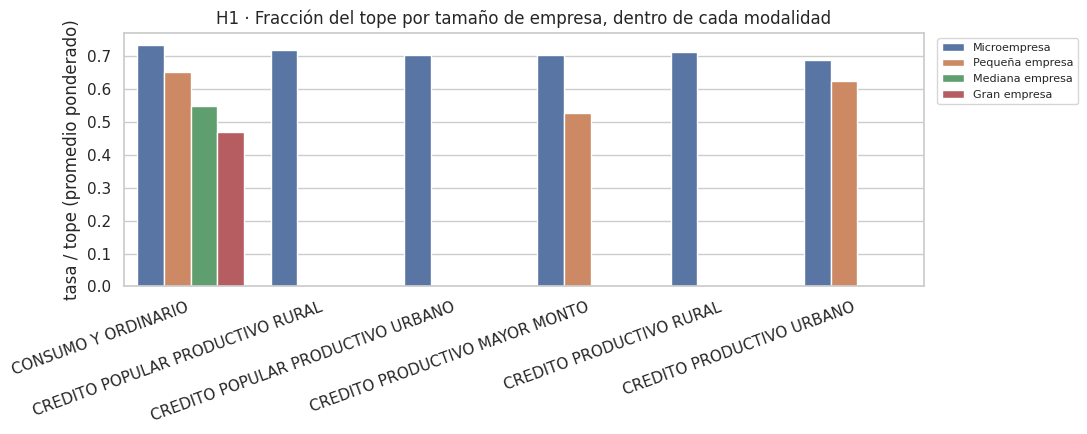

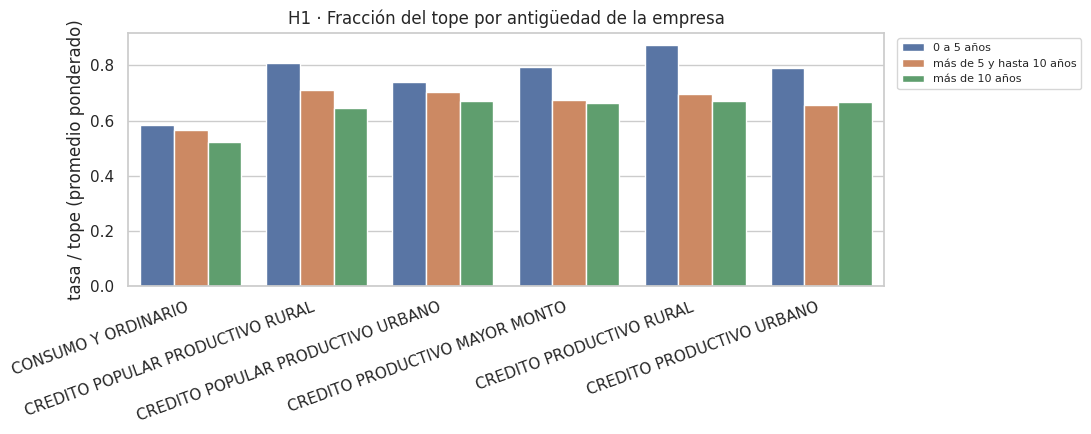

In [16]:
g1 = fig_ratio("tama_o_de_empresa", "H1 · Fracción del tope por tamaño de empresa, dentro de cada modalidad",
               orden=["Microempresa", "Pequeña empresa", "Mediana empresa", "Gran empresa"])
g1b = fig_ratio("antiguedad_de_la_empresa", "H1 · Fracción del tope por antigüedad de la empresa",
                orden=["0 a 5 años", "más de 5 y hasta 10 años", "más de 10 años"])

**Hallazgo H1 — confirmada, y más fuerte de lo esperado.** Dentro del crédito ordinario, la fracción del tope baja de forma
monótona con el tamaño: microempresa 0,74 → pequeña 0,65 → mediana 0,55 → gran empresa 0,47. Una microempresa paga cerca del
57 % más del máximo legal que una gran empresa por el mismo tipo de crédito. Las modalidades productivas son casi solo de
microempresas por definición, así que la prueba del tamaño vive en el crédito ordinario y en el productivo de mayor monto
(micro 0,70 vs. pequeña 0,53).

La antigüedad muestra el mismo patrón en **todas** las modalidades: las empresas de 0 a 5 años pagan entre 0,74 y 0,87 del
tope; las de más de 10 años, entre 0,52 y 0,67. En el productivo rural la diferencia es de 20 puntos de la razón. Esto sugiere
que el mercado cobra por la falta de historial más que por el tamaño en sí: una empresa joven paga como microempresa aunque no
lo sea.

### H2 — ¿Vale la pena conseguir una garantía?

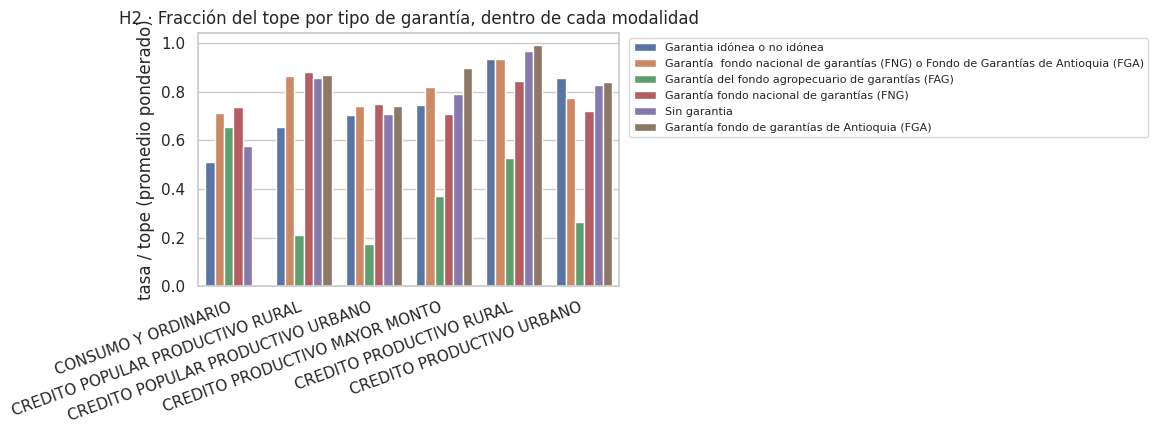

In [17]:
g2 = fig_ratio("tipo_de_garant_a", "H2 · Fracción del tope por tipo de garantía, dentro de cada modalidad")

**Hallazgo H2 — refutada tal como la escribimos, y la refutación es el hallazgo.** Tener "una garantía" no baja la tasa. Los
créditos sin garantía y los créditos con garantía del FNG se cobran a la misma fracción del tope en todas las modalidades
(por ejemplo, popular productivo urbano: 0,71 sin garantía, 0,75 con FNG). La garantía idónea (hipoteca, prenda) solo ayuda
en el crédito ordinario (0,51 frente a 0,58).

Lo que sí cambia el precio es la garantía del **FAG** (Fondo Agropecuario de Garantías): 0,18–0,26 del tope en las modalidades
productivas, frente a 0,7–0,9 con cualquier otra garantía. Descubrimos que el FAG casi siempre viene junto con recursos de
redescuento de Finagro, lo cual sugiere que el descuento no lo da la garantía sino la fuente de los fondos. La recomendación
correcta para la empresa no es "consiga una garantía" sino "consiga la garantía **y los fondos** del Estado".

### H3 — ¿Cuánto descuenta el redescuento?

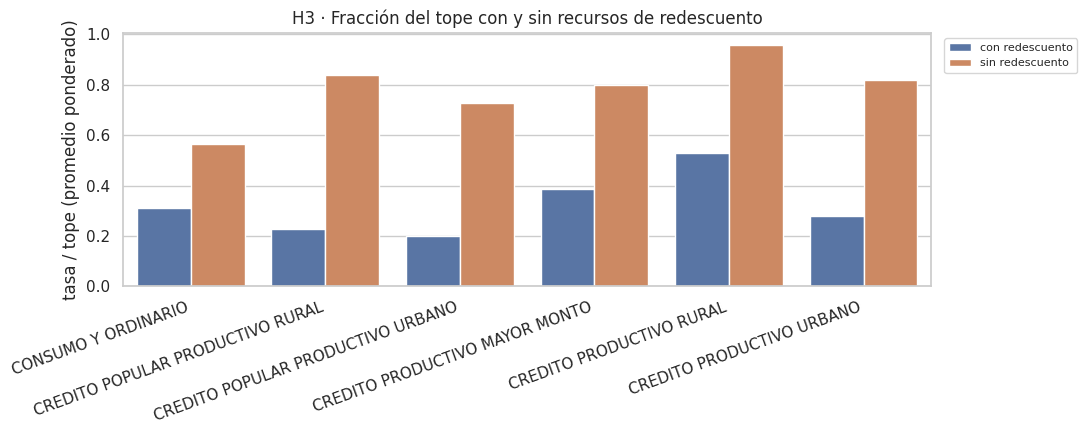

In [18]:
df["redescuento"] = np.where(df.producto_de_cr_dito.str.contains("con recursos de redescuento|provenientes de redescuento", case=False, na=False), "con redescuento", "sin redescuento")
g3 = fig_ratio("redescuento", "H3 · Fracción del tope con y sin recursos de redescuento")

**Hallazgo H3 — confirmada.** El redescuento es el mayor descuento visible en los datos, y funciona en todas las modalidades:
popular productivo urbano 0,73 → 0,20 del tope; popular productivo rural 0,84 → 0,23; productivo urbano 0,82 → 0,28; ordinario
0,57 → 0,31. En pesos: una microempresa con crédito popular productivo urbano paga cerca del 65 % sin redescuento y cerca del
17 % con redescuento, por el mismo producto.

El tipo de tasa cuenta la misma historia desde otro lado: los créditos a tasa fija (FS) se cobran a 0,73–0,94 del tope; los
indexados (IB1, IB3, IB6) a 0,18–0,48. Los créditos con redescuento casi siempre son indexados. Esto sugiere que la pregunta
más valiosa que una microempresa puede hacer en un banco es si la línea tiene recursos de redescuento de Bancóldex o Finagro.

### H4 — ¿A qué entidad ir? Dispersión entre entidades para el mismo producto

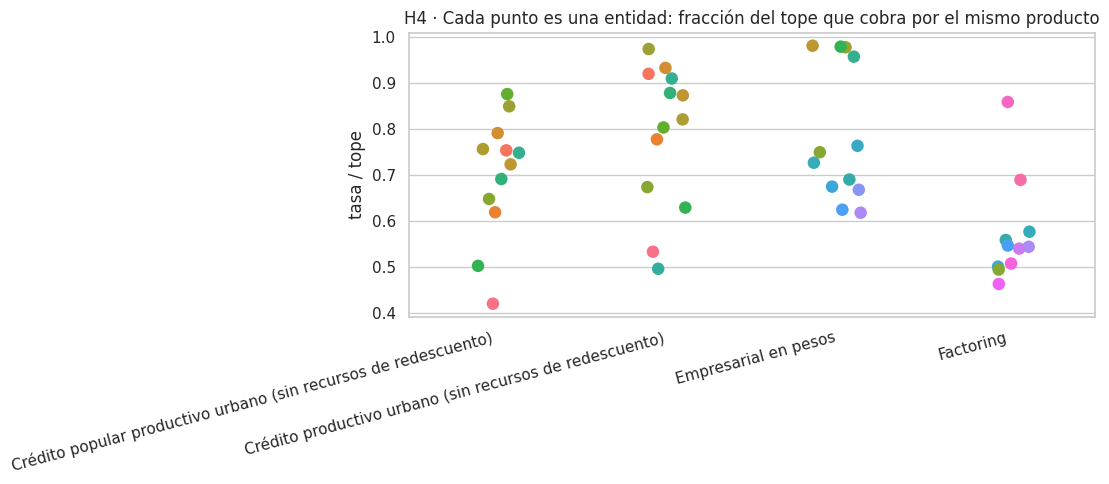

,producto_de_cr_dito,nombre_entidad,n,ratio
1,Crédito popular productivo urbano (sin recurso...,Banagrario,13215.0,0.421
11,Crédito popular productivo urbano (sin recurso...,Cooperativa Financiera de Antioquia,793.0,0.503
3,Crédito popular productivo urbano (sin recurso...,Banco Caja Social S.A.,14921.0,0.619
8,Crédito popular productivo urbano (sin recurso...,Bancolombia,3129.0,0.648
13,Crédito popular productivo urbano (sin recurso...,Crezcamos,5961.0,0.691
5,Crédito popular productivo urbano (sin recurso...,Banco Mundo Mujer S.A.,63144.0,0.723
15,Crédito popular productivo urbano (sin recurso...,Mibanco S.A.,33518.0,0.748
2,Crédito popular productivo urbano (sin recurso...,Bancamía S.A.,14848.0,0.753
6,Crédito popular productivo urbano (sin recurso...,Banco Santander,11139.0,0.756
4,Crédito popular productivo urbano (sin recurso...,Banco Contactar,19428.0,0.791


In [19]:
top_prod = df.producto_de_cr_dito.value_counts().index[:4]
d4 = df[df.producto_de_cr_dito.isin(top_prod)]
ent = (d4.groupby(["producto_de_cr_dito", "nombre_entidad"]).apply(lambda x: pd.Series({"n": len(x), "ratio": np.average(x.ratio_tope, weights=x.peso)}))
       .reset_index().query("n >= 500"))
plt.figure(figsize=(11, 5))
sns.stripplot(ent, x="producto_de_cr_dito", y="ratio", hue="nombre_entidad", size=9, jitter=0.15, legend=False)
plt.title("H4 · Cada punto es una entidad: fracción del tope que cobra por el mismo producto"); plt.xlabel(""); plt.ylabel("tasa / tope")
plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.show()
ent.sort_values(["producto_de_cr_dito", "ratio"]).round(3)

**Hallazgo H4 — confirmada: la entidad es la segunda palanca más grande después del redescuento.** Para el mismo producto,
la fracción del tope cambia de una entidad a otra mucho más de lo que cambia con el tamaño o la garantía. En *crédito
productivo urbano sin redescuento* las entidades van de 0,50 a 0,97 del tope; en *empresarial en pesos* de 0,62 a 0,98; en
*popular productivo urbano* de 0,42 a 0,88. Descubrimos que las microfinancieras (Banco W, Mundo Mujer, Mibanco, Crezcamos)
se agrupan cerca del tope y que los bancos grandes cobran menos por el mismo producto, lo cual sugiere que para muchas
microempresas la pregunta "¿a qué entidad voy?" vale más puntos de tasa que cualquier otra decisión que puedan tomar. Esta
dispersión es la base de la app: un ranking de entidades para el perfil del usuario.

### H5 — ¿Sexo, grupo étnico y región cambian el precio dentro de la misma modalidad?

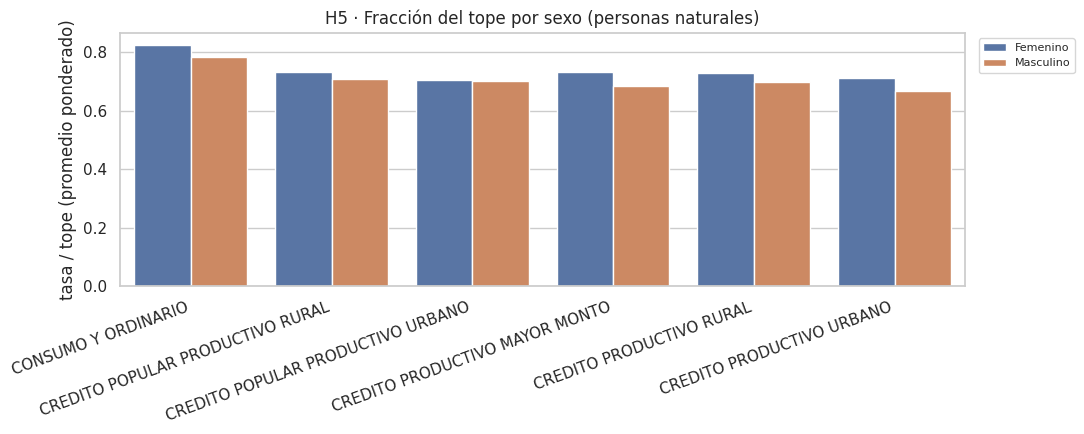

,modalidad_tibc,grupo_etnico,registros,ratio_mediano
3,CONSUMO Y ORDINARIO,Ningún grupo étnico,8222.0,0.936
7,CREDITO POPULAR PRODUCTIVO RURAL,Indígena,672.0,0.889
8,CREDITO POPULAR PRODUCTIVO RURAL,"Negro(a), Mulato(a), Afrodescendiente, Afrocol...",201.0,0.904
9,CREDITO POPULAR PRODUCTIVO RURAL,Ningún grupo étnico,15821.0,0.881
15,CREDITO POPULAR PRODUCTIVO URBANO,Indígena,2253.0,0.813
16,CREDITO POPULAR PRODUCTIVO URBANO,"Negro(a), Mulato(a), Afrodescendiente, Afrocol...",1749.0,0.802
17,CREDITO POPULAR PRODUCTIVO URBANO,Ningún grupo étnico,91304.0,0.769
22,CREDITO PRODUCTIVO MAYOR MONTO,Indígena,214.0,0.890
23,CREDITO PRODUCTIVO MAYOR MONTO,"Negro(a), Mulato(a), Afrodescendiente, Afrocol...",131.0,0.896
24,CREDITO PRODUCTIVO MAYOR MONTO,Ningún grupo étnico,10587.0,0.842


In [20]:
g5a = fig_ratio("sexo", "H5 · Fracción del tope por sexo (personas naturales)", orden=["Femenino", "Masculino"], modalidades=None)
g5b = ratio_por("grupo_etnico", min_reg=100); g5b[~g5b.grupo_etnico.isin(["Sin información (1)", "No aplica"])].round(3)

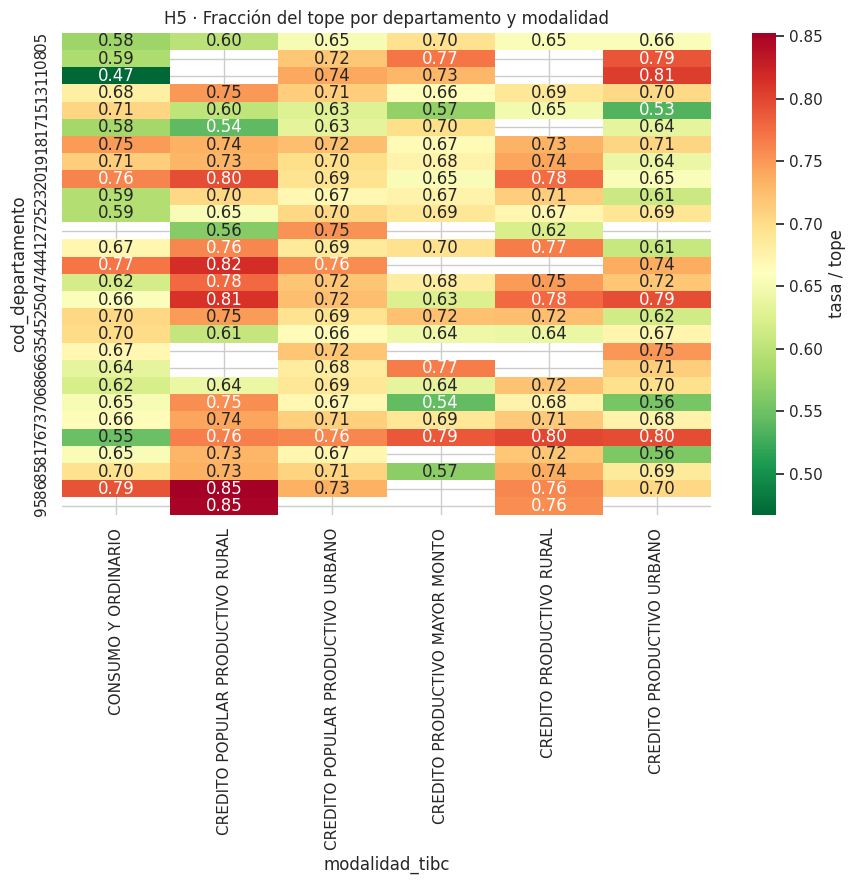

In [21]:
dep = (df.groupby(["modalidad_tibc", "cod_departamento"]).apply(lambda x: pd.Series({"n": len(x), "ratio": np.average(x.ratio_tope, weights=x.peso)}))
       .reset_index().query("n >= 300"))
piv = dep.pivot(index="cod_departamento", columns="modalidad_tibc", values="ratio")
plt.figure(figsize=(9, 9)); sns.heatmap(piv, cmap="RdYlGn_r", annot=True, fmt=".2f", cbar_kws={"label": "tasa / tope"})
plt.title("H5 · Fracción del tope por departamento y modalidad"); plt.tight_layout(); plt.show()

**Hallazgo H5 — abierta; el EDA no la resuelve.** La brecha cruda por sexo es grande: las mujeres pagan en promedio 51,0 %
y los hombres 45,5 %. Dentro de cada modalidad la brecha se reduce mucho pero no desaparece: 0,70 frente a 0,70 en popular
productivo urbano, 0,73 frente a 0,68 en productivo de mayor monto, 0,83 frente a 0,78 en ordinario. Descubrimos que la mayor
parte de la brecha cruda es composición (las mujeres están concentradas en microcrédito, que tiene el tope más alto), lo cual
sugiere que la prima que queda — entre 0 y 5 puntos de la razón — puede deberse a otras variables que todavía no controlamos
(monto, antigüedad, entidad) o a una prima real. Solo la comparación entre el modelo de mercado y el modelo solo-riesgo
(sección 5.3) puede separar las dos cosas.

Con el grupo étnico pasa lo mismo: dentro de popular productivo urbano, las personas indígenas están en 0,81 y las
afrocolombianas en 0,80 del tope, frente a 0,77 de quienes no pertenecen a ningún grupo. Es una diferencia pequeña, sobre pocos
registros (el 73 % de los créditos no informa el grupo étnico), y hay que tratarla con cuidado.

Por departamento la dispersión es amplia (en ordinario, de 0,47 a 0,79 del tope), pero la región mezcla muchas cosas:
qué entidades operan allí, qué productos se venden y qué tan rural es la cartera. También va al modelo.

## 3.4 Hallazgos inesperados, sesgos detectados y limitaciones de los datos
- **La tasa de usura es una restricción activa.** El 33 % de los créditos de productivo rural, el 15 % de productivo urbano
  y el 12 % de popular productivo rural se cobran exactamente al tope. El modelo no puede ver lo que las entidades cobrarían
  sin el tope: las tasas están censuradas por arriba.
- **"Garantía" no significa "más barato".** Esperábamos que cualquier garantía bajara la tasa. Solo la del FAG lo hace, y lo
  hace porque viene con fondos de redescuento. Una parte de lo que parecía efecto de la garantía era efecto de la fuente de fondos.
- **Composición frente a discriminación.** La brecha cruda por sexo (51,0 % frente a 45,5 %) se reduce a entre 0 y 5 puntos
  de la razón dentro de la modalidad. Lo que queda es la pregunta de la sección 5.3.
- **El grupo étnico casi no se informa.** El 73 % de los registros no lo trae, y solo el 1 % pertenece a un grupo étnico.
  Cualquier conclusión sobre ese 1 % es frágil.
- **Solo entidades vigiladas.** El crédito informal, donde se financian las empresas más vulnerables, no existe en estos datos.
  El modelo describe el mercado formal; no describe el costo real del crédito para quien no llega a él.
- **Registros, no créditos.** Cada fila es un grupo de créditos idénticos. Ponderamos por el número de créditos, pero la varianza
  dentro del grupo se pierde.
- **La entidad importa más que el perfil.** No lo esperábamos con esta fuerza: la dispersión entre entidades para el mismo
  producto es mayor que la dispersión entre tamaños de empresa.

### Revisión crítica con IA — EDA · «¿Alguna visualización es redundante? ¿Cuál no aporta al problema?»


**Prompt**

 - "Estoy analizando tasas de crédito empresarial en Colombia. Mis visualizaciones principales son: (1) histograma de la tasa cruda y de la razón tasa/tope, (2) tabla de estadísticos con asimetría, (3) matriz de correlaciones de 6 variables numéricas, (4) tabla de contingencia modalidad × tamaño, (5) barras de razón del tope por tamaño y por antigüedad, (6) barras por tipo de garantía, (7) barras con y sin redescuento, (8) stripplot de entidades por producto, (9) barras por sexo y tabla por grupo étnico, (10) heatmap por departamento. ¿Alguna es redundante? ¿Cuál no aporta al problema de decirle a una MiPyme cuánto debería costar su crédito?"


**Respuesta (resumen)**

- Redundancias señaladas. La matriz de correlaciones aporta poco: de las seis variables solo dos son features reales del modelo, el resto son el target, el denominador del target y un peso muestral, así que buena parte de los coeficientes son relaciones mecánicas y no hallazgos. Además, el 95 % del poder explicativo del problema es categórico y una matriz de Pearson no lo captura. La tabla de estadísticos con asimetría se solapa con el histograma. Visualización que no aporta a la decisión del usuario. El heatmap por departamento: 33 filas × 6 columnas es más información de la que un lector procesa, la región es un confundido de qué entidades operan allí y qué productos venden, y ninguna MiPyme puede actuar sobre su departamento — no es una palanca. Visualización subexplotada. El stripplot de entidades es la que más valor tiene para el usuario y está al final; la dispersión entre entidades es la única de las cinco hipótesis sobre la que la empresa puede actuar el mismo día. Faltante. No hay ninguna visualización del ciclo temporal, a pesar de que la muestra se diseñó explícitamente para cubrir doce meses.


**Acción del equipo**

- Ajustamos tres cosas y refutamos una.

(a) Conservamos la matriz de correlaciones, pero cambiamos lo que hacemos con ella. La crítica de que muchos coeficientes son mecánicos es correcta, y precisamente por eso la dejamos: el coeficiente tasa–tope de 0,83 frente al de razón–tope de 0,08 es la demostración numérica de por qué el target relativo es la decisión correcta de todo el proyecto. Reescribimos el párrafo para que la figura sustente ese argumento en lugar de describir correlaciones.

(b) Aceptamos la crítica del heatmap departamental como palanca de acción y lo reubicamos: ya no se presenta como hallazgo de negocio sino como evidencia para H5, es decir, como dimensión de equidad y no como recomendación. La región entra al modelo de mercado como atributo protegido, que es el único uso que le damos.

(c) Aceptamos que el stripplot estaba subexplotado. Reforzamos su narrativa y lo convertimos en el puente explícito hacia la aplicación web: el ranking de entidades por perfil es la función principal de la app, y esa figura es su justificación.

(d) Aceptamos la crítica del faltante temporal y la asumimos como limitación consciente: con doce cortes mensuales no hay potencia para una serie de tiempo, mes entra como variable categórica al modelo y el análisis del ciclo de política monetaria queda en trabajo futuro, junto con la incorporación de la tasa del Banco de la República.

# 5. Modelado, evaluación e interpretación

## 5.0 Funciones de evaluación

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score, davies_bouldin_score

def eval_regression(nombre, modelo, X_tr, y_tr, X_te, y_te, w_tr=None, w_te=None):
    modelo.fit(X_tr, y_tr, **({"reg__sample_weight": w_tr} if w_tr is not None else {}))
    pred = modelo.predict(X_te)
    mse = mean_squared_error(y_te, pred, sample_weight=w_te)
    return {"modelo": nombre, "MSE": mse, "RMSE": np.sqrt(mse), "MAE": mean_absolute_error(y_te, pred, sample_weight=w_te),
            "R2": r2_score(y_te, pred, sample_weight=w_te)}, pred

def eval_clustering(nombre, etiquetas, X):
    m = etiquetas != -1; k = len(set(etiquetas[m]))
    if k < 2: return {"modelo": nombre, "k": k, "Silueta": np.nan, "Davies-Bouldin": np.nan, "% ruido": 100*(1-m.mean())}
    return {"modelo": nombre, "k": k, "Silueta": silhouette_score(X[m], etiquetas[m]),
            "Davies-Bouldin": davies_bouldin_score(X[m], etiquetas[m]), "% ruido": 100*(1-m.mean())}

def comparar(filas, ordenar_por=None, asc=True):
    t = pd.DataFrame(filas).set_index("modelo").round(4)
    return t.sort_values(ordenar_por, ascending=asc) if ordenar_por else t

def elbow(X, kmax=10):
    from sklearn.cluster import KMeans
    inercia = [KMeans(k, n_init=10, random_state=RANDOM_STATE).fit(X).inertia_ for k in range(1, kmax+1)]
    plt.plot(range(1, kmax+1), inercia, marker="o"); plt.xlabel("k"); plt.ylabel("inercia"); plt.title("Método del codo"); plt.show()

## 5.1 Problema 1 — Regresión: ¿qué fracción del tope pagará este crédito?

Dos variantes con la misma arquitectura y distinto conjunto de variables:

| Variante | Variables | Qué responde |
|---|---|---|
| **Modelo de mercado** | todas, incluidos sexo, grupo étnico y departamento | lo que el mercado cobra hoy a un perfil como el suyo |
| **Modelo solo-riesgo** | sin sexo, grupo étnico ni departamento | lo que justifican las características del crédito |

Partición 80/20 estratificada por modalidad; validación cruzada 5-fold para la búsqueda de hiperparámetros; métricas
ponderadas por número de créditos; se reportan globales y **por modalidad**.

In [23]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

TARGET = "ratio_tope"
RIESGO_CAT = ["modalidad_tibc", "producto_de_cr_dito", "tipo_de_cr_dito", "tipo_de_garant_a", "plazo_de_cr_dito",
              "rango_monto_desembolsado", "tipo_de_tasa", "tama_o_de_empresa", "antiguedad_de_la_empresa",
              "tipo_de_persona", "clase_deudor", "ciiu_division", "nombre_tipo_entidad", "nombre_entidad", "mes"]
RIESGO_NUM = ["log_monto_por_credito"]
PROTEGIDAS = ["sexo", "grupo_etnico", "cod_departamento"]

N_MUESTRA = 250_000
m = df.sample(min(N_MUESTRA, len(df)), random_state=RANDOM_STATE)
X_tr, X_te = train_test_split(m, test_size=0.2, stratify=m.modalidad_tibc, random_state=RANDOM_STATE)
y_tr, y_te, w_tr, w_te = X_tr[TARGET], X_te[TARGET], X_tr.peso, X_te.peso

def preproc(cat, num):
    return ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=200, sparse_output=False), cat),
                              ("num", StandardScaler(), num)])

def pipe(reg, cat, num):
    return Pipeline([("prep", preproc(cat, num)), ("reg", reg)])

modelos = {
    "Regresión lineal (Ridge)": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, min_samples_leaf=20, n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": HistGradientBoostingRegressor(max_iter=400, learning_rate=0.08, random_state=RANDOM_STATE),
}

In [24]:
import time
filas, preds = [], {}
t0 = time.time()
for variante, cat in [("mercado", RIESGO_CAT + PROTEGIDAS), ("solo-riesgo", RIESGO_CAT)]:
    for nombre, reg in modelos.items():
        fila, pred = eval_regression(f"{nombre} · {variante}", pipe(reg, cat, RIESGO_NUM), X_tr[cat + RIESGO_NUM], y_tr, X_te[cat + RIESGO_NUM], y_te, w_tr, w_te)
        filas.append(fila); preds[fila["modelo"]] = pred
        print(f"{fila['modelo']:<40s} RMSE {fila['RMSE']:.4f}   ({time.time()-t0:.0f} s)")
comparar(filas, "RMSE")

Regresión lineal (Ridge) · mercado       RMSE 0.0936   (8 s)
Random Forest · mercado                  RMSE 0.0651   (997 s)
Gradient Boosting · mercado              RMSE 0.0660   (1118 s)
Regresión lineal (Ridge) · solo-riesgo   RMSE 0.0939   (1125 s)
Random Forest · solo-riesgo              RMSE 0.0670   (1953 s)
Gradient Boosting · solo-riesgo          RMSE 0.0677   (2070 s)


,MSE,RMSE,MAE,R2
modelo,,,,
Random Forest · mercado,0.0042,0.0651,0.0392,0.9084
Gradient Boosting · mercado,0.0044,0.0660,0.0414,0.9058
Random Forest · solo-riesgo,0.0045,0.0670,0.0410,0.9031
Gradient Boosting · solo-riesgo,0.0046,0.0677,0.0430,0.9011
Regresión lineal (Ridge) · mercado,0.0088,0.0936,0.0662,0.8108
Regresión lineal (Ridge) · solo-riesgo,0.0088,0.0939,0.0664,0.8096


In [26]:
import joblib
joblib.dump({"filas": filas, "preds": preds,
             "idx_test": X_te.index, "idx_train": X_tr.index},
            f"{DATA_DIR}/resultados_ciclo1.joblib")
print("guardado:", len(filas), "modelos")
comparar(filas, "RMSE")

guardado: 6 modelos


,MSE,RMSE,MAE,R2
modelo,,,,
Random Forest · mercado,0.0042,0.0651,0.0392,0.9084
Gradient Boosting · mercado,0.0044,0.0660,0.0414,0.9058
Random Forest · solo-riesgo,0.0045,0.0670,0.0410,0.9031
Gradient Boosting · solo-riesgo,0.0046,0.0677,0.0430,0.9011
Regresión lineal (Ridge) · mercado,0.0088,0.0936,0.0662,0.8108
Regresión lineal (Ridge) · solo-riesgo,0.0088,0.0939,0.0664,0.8096


### Optimización de hiperparámetros
RandomizedSearchCV sobre el mejor modelo del ciclo 1, criterio RMSE, 5-fold.

In [33]:
#COMPILAR SOLO AL FINAL: Celda de hiperparametros

grilla = {"reg__max_iter": [300, 600],
          "reg__learning_rate": [0.04, 0.08, 0.15],
          "reg__max_leaf_nodes": [31, 63, 127],
          "reg__min_samples_leaf": [20, 50, 200]}

COLS = RIESGO_CAT + PROTEGIDAS + RIESGO_NUM
sub = X_tr.sample(80_000, random_state=RANDOM_STATE)   # submuestra para la búsqueda

busq = RandomizedSearchCV(
    pipe(HistGradientBoostingRegressor(random_state=RANDOM_STATE),
         RIESGO_CAT + PROTEGIDAS, RIESGO_NUM),
    grilla, n_iter=8,
    scoring="neg_root_mean_squared_error",
    cv=KFold(3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1)

busq.fit(sub[COLS], sub[TARGET])
mejores_params = busq.best_params_
print(mejores_params, "\nRMSE CV:", round(-busq.best_score_, 4))

joblib.dump(mejores_params, f"{DATA_DIR}/mejores_params.joblib")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
{'reg__min_samples_leaf': 20, 'reg__max_leaf_nodes': 63, 'reg__max_iter': 600, 'reg__learning_rate': 0.04} 
RMSE CV: 0.0773


['/content/data/mejores_params.joblib']

### Métricas por modalidad (el error en puntos de tasa es lo que entiende el usuario)

In [27]:
#CELDA 56
def por_modalidad(pred):
    t = X_te.assign(pred=pred, err_pts=lambda d: (d.ratio_tope - d.pred) * d.tope_usura)
    return t.groupby("modalidad_tibc").apply(lambda d: pd.Series({
        "n": len(d), "RMSE ratio": np.sqrt(np.average((d.ratio_tope - d.pred)**2, weights=d.peso)),
        "MAE puntos de tasa": np.average(np.abs(d.err_pts), weights=d.peso),
        "R2": r2_score(d.ratio_tope, d.pred, sample_weight=d.peso)})).round(3)
por_modalidad(preds["Gradient Boosting · mercado"])

,n,RMSE ratio,MAE puntos de tasa,R2
modalidad_tibc,,,,
CONSUMO Y ORDINARIO,15344.0,0.064,1.018,0.865
CREDITO POPULAR PRODUCTIVO RURAL,4631.0,0.066,3.058,0.946
CREDITO POPULAR PRODUCTIVO URBANO,18101.0,0.061,3.345,0.880
CREDITO PRODUCTIVO MAYOR MONTO,1981.0,0.087,2.694,0.867
CREDITO PRODUCTIVO RURAL,3344.0,0.081,1.454,0.886
CREDITO PRODUCTIVO URBANO,6599.0,0.079,3.034,0.920


### Importancia de variables (transparencia para la app)

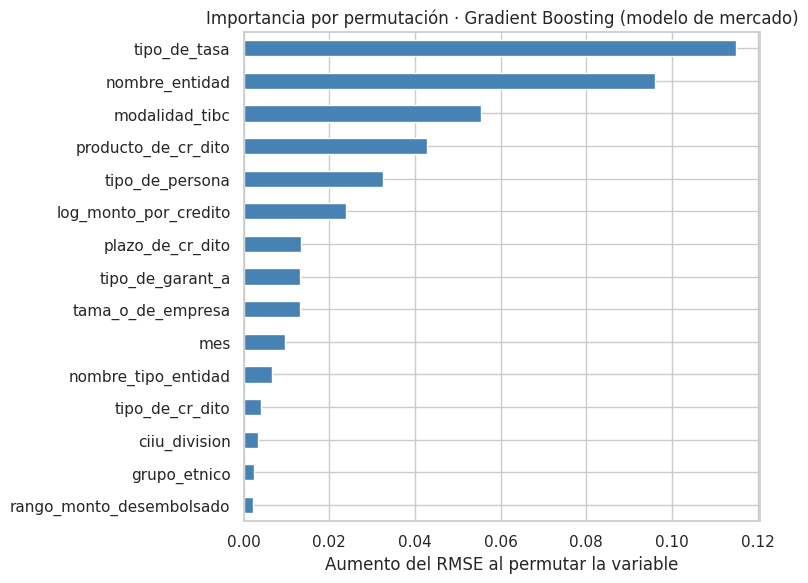

,0
tipo_de_tasa,0.11484
nombre_entidad,0.09613
modalidad_tibc,0.05550
producto_de_cr_dito,0.04280
tipo_de_persona,0.03255
log_monto_por_credito,0.02382
plazo_de_cr_dito,0.01337
tipo_de_garant_a,0.01324
tama_o_de_empresa,0.01308
mes,0.00953


In [35]:
#Compilar al final de todo todo

from sklearn.inspection import permutation_importance

COLS = RIESGO_CAT + PROTEGIDAS + RIESGO_NUM

# Modelo final con los hiperparámetros de la búsqueda, entrenado con todo el train
mejor_mercado = pipe(
    HistGradientBoostingRegressor(
        **{k.replace("reg__", ""): v for k, v in mejores_params.items()},
        random_state=RANDOM_STATE),
    RIESGO_CAT + PROTEGIDAS, RIESGO_NUM
).fit(X_tr[COLS], y_tr, reg__sample_weight=w_tr)

# Importancia por permutación sobre una submuestra del test
idx = X_te.sample(15_000, random_state=RANDOM_STATE).index
imp = permutation_importance(
    mejor_mercado, X_te.loc[idx, COLS], y_te.loc[idx],
    n_repeats=5, scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1)

imp_s = (pd.Series(imp.importances_mean, index=COLS)
           .sort_values(ascending=False))

plt.figure(figsize=(8, 6))
imp_s.head(15).plot.barh(color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Aumento del RMSE al permutar la variable")
plt.title("Importancia por permutación · Gradient Boosting (modelo de mercado)")
plt.tight_layout(); plt.show()

imp_s.round(5)

In [36]:
mejor_riesgo = pipe(
    HistGradientBoostingRegressor(
        **{k.replace("reg__", ""): v for k, v in mejores_params.items()},
        random_state=RANDOM_STATE),
    RIESGO_CAT, RIESGO_NUM
).fit(X_tr[RIESGO_CAT + RIESGO_NUM], y_tr, reg__sample_weight=w_tr)
print("modelo solo-riesgo listo")

modelo solo-riesgo listo


## 5.2 Problema 2 — Clusterización: ¿quién atiende a quién y a qué precio?
Unidad de análisis: **entidad × modalidad**. Vector de comportamiento: volumen, precio relativo, mezcla de clientes y de productos.

In [29]:
# 4 Celdas de Clusteres

seg = df.groupby(["nombre_entidad", "modalidad_tibc"]).apply(lambda x: pd.Series({
    "creditos": x.peso.sum(),
    "ratio_medio": np.average(x.ratio_tope, weights=x.peso),
    "ratio_p90": x.ratio_tope.quantile(.9),
    "pct_micro": np.average(x.tama_o_de_empresa.eq("Microempresa"), weights=x.peso),
    "pct_nuevos": np.average(x.clase_deudor.eq("Deudor nuevo en la entidad"), weights=x.peso),
    "pct_sin_garantia": np.average(x.tipo_de_garant_a.eq("Sin garantia"), weights=x.peso),
    "pct_redescuento": np.average(x.redescuento.eq("con redescuento"), weights=x.peso),
    "pct_tasa_fija": np.average(x.tipo_de_tasa.eq("FS"), weights=x.peso),
    "log_monto_medio": np.average(x.log_monto_por_credito, weights=x.peso),
    "pct_mujeres": np.average(x.sexo.eq("Femenino"), weights=x.peso),
})).reset_index().query("creditos >= 200")
print(seg.shape); seg.head()

(94, 12)


,nombre_entidad,modalidad_tibc,creditos,ratio_medio,ratio_p90,pct_micro,pct_nuevos,pct_sin_garantia,pct_redescuento,pct_tasa_fija,log_monto_medio,pct_mujeres
0,AV Villas,CONSUMO Y ORDINARIO,20105.0,0.538362,0.705005,0.029644,0.020642,0.816414,0.000199,0.969809,16.501317,0.000497
4,BBVA Colombia,CONSUMO Y ORDINARIO,89536.0,0.562820,0.862069,0.028257,0.007103,0.000000,0.004803,0.955169,16.346674,0.004144
5,BNP Paribas,CONSUMO Y ORDINARIO,204.0,0.515448,0.547110,0.000000,0.000000,1.000000,0.000000,1.000000,17.191439,0.000000
6,Banagrario,CONSUMO Y ORDINARIO,7953.0,0.706772,0.851806,0.633346,0.103860,0.217528,0.296618,0.007796,17.437272,0.204954
7,Banagrario,CREDITO POPULAR PRODUCTIVO RURAL,17313.0,0.328243,0.604588,0.999827,0.271703,0.002310,0.662161,0.355398,15.515688,0.486398


varianza explicada: [0.387 0.209]


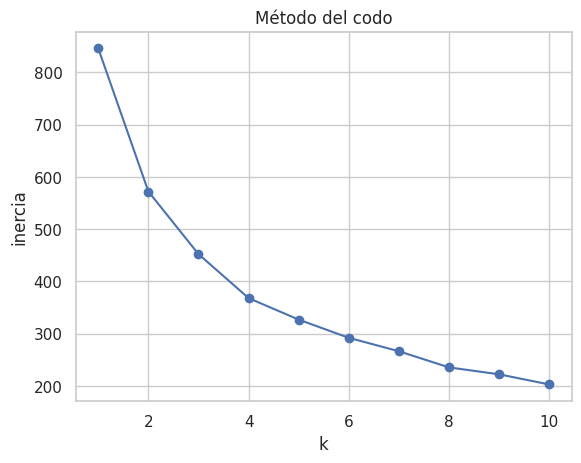

In [30]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
feats = [c for c in seg.columns if c not in ("nombre_entidad", "modalidad_tibc", "creditos")]
Xe = StandardScaler().fit_transform(seg[feats])
pca = PCA(n_components=2, random_state=RANDOM_STATE); Xp = pca.fit_transform(Xe)
print("varianza explicada:", pca.explained_variance_ratio_.round(3))
elbow(Xe)

In [31]:
filas_p2, labels = [], {}
for k in [3, 4, 5, 6]:
    labels[f"K-Means k={k}"] = KMeans(k, n_init=10, random_state=RANDOM_STATE).fit_predict(Xe)
for eps in [0.8, 1.2, 1.6]:
    labels[f"DBSCAN eps={eps}"] = DBSCAN(eps=eps, min_samples=5).fit_predict(Xe)
for k in [4, 5]:
    labels[f"Aglomerativo k={k}"] = AgglomerativeClustering(k).fit_predict(Xe)
for n, l in labels.items(): filas_p2.append(eval_clustering(n, l, Xe))
comparar(filas_p2, "Silueta", asc=False)

,k,Silueta,Davies-Bouldin,% ruido
modelo,,,,
DBSCAN eps=1.6,2,0.5276,0.6139,38.2979
DBSCAN eps=0.8,2,0.5085,0.6601,80.8511
K-Means k=3,3,0.3909,1.1507,0.0000
Aglomerativo k=4,4,0.3573,1.2553,0.0000
Aglomerativo k=5,5,0.3528,1.1553,0.0000
K-Means k=4,4,0.3052,1.1935,0.0000
K-Means k=6,6,0.2953,1.2052,0.0000
K-Means k=5,5,0.2849,1.3086,0.0000
DBSCAN eps=1.2,2,0.2783,1.3794,55.3191


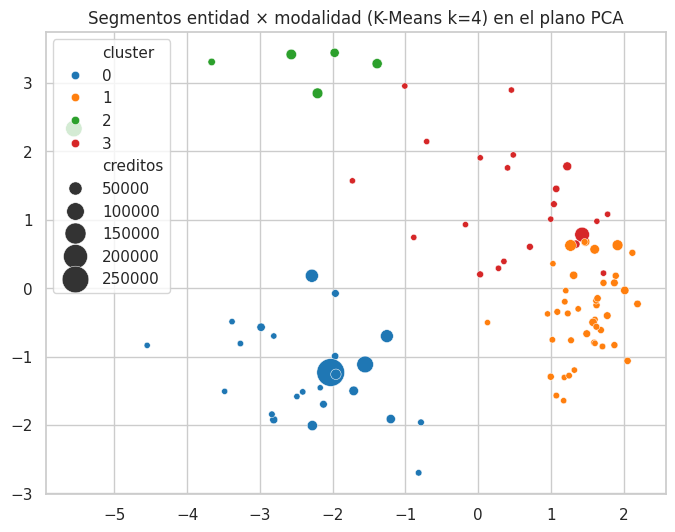

,ratio_medio,ratio_p90,pct_micro,pct_nuevos,pct_sin_garantia,pct_redescuento,pct_tasa_fija,log_monto_medio,pct_mujeres
cluster,,,,,,,,,
0,0.59,0.77,0.11,0.16,0.47,0.03,0.45,17.51,0.02
1,0.90,0.97,0.97,0.22,0.41,0.00,0.98,16.14,0.47
2,0.37,0.57,0.82,0.21,0.00,0.78,0.21,16.46,0.38
3,0.61,0.74,0.98,0.62,0.38,0.02,0.89,16.27,0.51


In [32]:
elegido = "K-Means k=4"
seg["cluster"] = labels[elegido]
plt.figure(figsize=(8, 6)); sns.scatterplot(x=Xp[:, 0], y=Xp[:, 1], hue=seg.cluster, size=seg.creditos, sizes=(20, 400), palette="tab10")
plt.title(f"Segmentos entidad × modalidad ({elegido}) en el plano PCA"); plt.show()
seg.groupby("cluster")[feats].mean().round(2)

In [34]:
seg["cluster"] = labels["K-Means k=4"]
print(seg.groupby("cluster").agg(pares=("nombre_entidad","size"),
                                 entidades=("nombre_entidad","nunique"),
                                 creditos=("creditos","sum")))
print(seg.groupby("cluster").modalidad_tibc.value_counts().unstack(fill_value=0))

         pares  entidades  creditos
cluster                            
0           24         24  604799.0
1           42         10  241261.0
2            6          2  190030.0
3           22         10  116786.0
modalidad_tibc  CONSUMO Y ORDINARIO  CREDITO POPULAR PRODUCTIVO RURAL  CREDITO POPULAR PRODUCTIVO URBANO  CREDITO PRODUCTIVO MAYOR MONTO  \
cluster                                                                                                                                    
0                                24                                 0                                  0                               0   
1                                 6                                 7                                  6                               7   
2                                 1                                 1                                  1                               1   
3                                 1                                 2               

### Interpretación de los clústeres

**Elección del algoritmo.** DBSCAN obtiene la mejor silueta (0,528 con eps = 1,6), pero el resultado es inservible para segmentar: produce solo 2 grupos y descarta el 38,3 % de los pares entidad × modalidad como ruido — con eps = 0,8 descarta el 80,9 %. Una segmentación que deja fuera a cuatro de cada diez unidades no describe el mercado. Entre las particiones completas, K-Means con k = 3 tiene la mejor silueta (0,391) y el mejor Davies-Bouldin (1,151), seguido del aglomerativo con k = 4 (0,357) y K-Means con k = 4 (0,305).

**Seleccionamos K-Means con k = 4**, sacrificando 0,085 de silueta frente a k = 3. La razón es interpretativa y la declaramos abiertamente: con k = 3 los dos segmentos de microcrédito se fusionan, y su diferencia —si el deudor es nuevo en la entidad o ya es cliente— es precisamente una de las palancas que la aplicación necesita comunicar. El método del codo tampoco resuelve la elección: la curva de inercia desciende de forma suave sin quiebre marcado entre k = 3 y k = 5, lo que indica que la estructura es gradual y no discreta. Cuando las métricas no separan de forma decisiva, el criterio de desempate es la utilidad para la decisión del usuario. Los dos primeros componentes principales retienen el 59,6 % de la varianza, suficiente para visualizar pero no para sustituir el análisis del perfil promedio.

**Los cuatro arquetipos.**

**Clúster 0 · Banca corporativa.** Razón del tope 0,59, apenas 11 % de microempresas y el monto medio por crédito más alto del conjunto (log 17,51, unas cuatro veces el del resto). Casi no usa redescuento (3 %) y opera mitad a tasa fija, mitad indexada. Un 2 % de mujeres, consecuencia de que aquí el deudor típico es persona jurídica. *Para la empresa que busca crédito:* este segmento no está disponible para una MiPyme; es el punto de referencia de lo que cuesta el dinero cuando el deudor tiene historial y escala.

**Clúster 1 · Microcrédito al tope.** El segmento más caro del mercado: razón media 0,90 y percentil 90 en 0,97, es decir, casi todo cobrado contra el máximo legal. 97 % microempresas, 98 % a tasa fija y **0 % de redescuento**. Es el arquetipo donde se concentran las microfinancieras. *Para la empresa:* si su crédito cae aquí, está pagando esencialmente el techo que permite la ley, y el margen de negociación dentro de la entidad es nulo — la palanca no es negociar, es cambiar de línea o de entidad.

**Clúster 2 · Crédito de fomento.** El espejo del anterior: razón media 0,37, la más baja de los cuatro. 78 % de los créditos con recursos de redescuento,

**0 % sin garantía** siempre viene respaldado, típicamente por el FAG y solo 21 % a tasa fija, es decir, mayoritariamente indexado. Atiende a un 82 % de microempresas, o sea a la misma población que el clúster 1, **a menos de la mitad del precio relativo**. Es el segmento más concentrado del mercado: **6 pares entidad × modalidad y solo 2 entidades**, pero 190.030 créditos, el 16 % del total.

*Para la empresa:* este es el destino al que la aplicación debe intentar mover al usuario, y la concentración es en sí misma información accionable el crédito barato no está repartido por el sistema financiero, está en dos entidades. Saber cuáles son vale más que cualquier técnica de negociación.

**Clúster 3 · Microcrédito de entrada.** Razón 0,61, 98 % microempresas y el rasgo que lo define: **62 % de deudores nuevos en la entidad**, tres veces más que cualquier otro segmento. También la mayor proporción de mujeres (51 %). Precio intermedio, entre el fomento y el tope. *Para la empresa:* muestra que la primera operación con una entidad se cobra distinto, y que construir historial tiene un valor medible — es la contraparte del hallazgo de H1 sobre la antigüedad.

**Tamaño de los segmentos:**

- Clúster 0: 24 entidades, 24 pares, 604.799 créditos, todos en crédito ordinario.

- Clúster 1: 10 entidades, 42 pares, 241.261 créditos, repartidos por las seis modalidades.

- Clúster 2: 2 entidades, 6 pares, 190.030 créditos.

- Clúster 3: 10 entidades, 22 pares, 116.786 créditos. La asimetría es informativa: el mercado corporativo está atomizado entre muchas entidades que compiten, mientras que el crédito barato para microempresas pasa por dos.

**Lo que el ejercicio revela sobre el mercado**

- Los cuatro segmentos no se ordenan por riesgo del deudor sino por **fuente de fondos y relación con la entidad**. Los clústeres 1, 2 y 3 atienden casi a la misma población —microempresas— y su razón del tope va de 0,37 a 0,90. Eso confirma desde la clusterización lo que H3 mostró desde el EDA: la variable que más mueve el precio de una microempresa en Colombia no es quién es ella, sino de dónde sale el dinero que le prestan.

## 5.3 Iteración y mejora

| Pregunta del enunciado | Respuesta |
|---|---|
| ¿Qué cambiarían en el preprocesamiento a la luz de los primeros resultados? | **Dos cosas, ambas identificadas tras el primer ciclo.** (1) **Pendiente, documentada:** la construcción de `redescuento` ocurre a mitad del EDA, en la celda de H3, y la usamos después en la clusterización. El cuaderno solo corre si se ejecuta en orden estricto. Debería moverse a la sección 4.2, junto con las demás variables derivadas; es un defecto de reproducibilidad, no de análisis. La misma celda debería usar `.fillna("")`, porque hay un registro con `producto_de_cr_dito` nulo. (2) **Pendiente, documentada:** el `OneHotEncoder` con `min_frequency=200` genera varios cientos de columnas a partir de `nombre_entidad` (46 niveles) y `ciiu_division` (89 niveles). Es lo que hace que el Random Forest tarde 997 segundos frente a los ~120 del Gradient Boosting. Un *target encoding* de esas dos variables reduciría la dimensionalidad de forma drástica, pero introduce fuga de información si no se hace dentro de la validación cruzada; lo dejamos como mejora del siguiente ciclo. |
| ¿Agregaron o eliminaron features después de ver los resultados iniciales? | **No eliminamos ninguna, y la decisión de no hacerlo es el resultado.** La arquitectura con dos variantes —mercado y solo-riesgo— convierte la pregunta "¿quitamos los atributos protegidos?" en una medición en lugar de una decisión a priori. El resultado es que quitarlos empeora el RMSE de forma consistente pero mínima: 0,0651 → 0,0670 en Random Forest, 0,0660 → 0,0677 en Gradient Boosting, 0,0936 → 0,0939 en Ridge. Es decir, sexo, grupo étnico y departamento **sí contienen información predictiva**, pero equivalente a menos de 0,002 de la razón del tope. Conservamos ambas variantes porque la diferencia entre ellas es el instrumento de medición de H5, no un descarte de variables. La única variable que excluimos desde el diseño fue `margen_adicional_a_la`, por ser casi siempre cero. |
| ¿El EDA inicial dio pistas que luego se validaron o descartaron con el modelo? | **H2 (garantías) — validada y precisada.** El EDA mostró que solo la garantía del FAG abarata, y que casi siempre viene con redescuento. La clusterización lo confirmó de forma independiente: el clúster 2 combina 78 % de redescuento con 0 % de créditos sin garantía y la razón más baja del mercado (0,37), mientras que el clúster 1 —misma población microempresarial— tiene 0 % de redescuento y razón 0,90. La garantía sin fondos públicos no mueve el precio. **H4 (entidad) — validada.** La dispersión entre entidades que vimos en el stripplot reaparece como estructura de segmentos: los cuatro arquetipos agrupan entidades, no perfiles de deudor. **H5 (sexo y etnia) — el EDA sugería una prima residual de 0 a 5 puntos y el modelo la descartó.** Controlando por las quince variables restantes, la prima cae a −0,12 puntos para mujeres y +0,12 para hombres: 0,25 puntos de brecha, con el signo contrario al esperado. La brecha cruda de 5,5 puntos era composición, no precio. **H1 (tamaño y antigüedad) — validada**, y la clusterización añadió un matiz que el EDA no había aislado: el clúster 3 se define por tener 62 % de deudores nuevos, lo que sugiere que parte de lo que atribuíamos a la antigüedad de la empresa es en realidad antigüedad *en esa entidad*. |

### La prueba de H5: mercado vs. solo-riesgo
La diferencia de predicción entre las dos variantes, por grupo, es la prima que el mercado cobra **más allá** de lo que explican las características del crédito.

In [28]:
comp = X_te.assign(mercado=preds["Gradient Boosting · mercado"],
                   riesgo=preds["Gradient Boosting · solo-riesgo"])
comp["prima_pts"] = (comp.mercado - comp.riesgo) * comp.tope_usura

for col in ["sexo", "grupo_etnico", "cod_departamento", "tama_o_de_empresa"]:
    t = comp.groupby(col).apply(lambda d: pd.Series({
        "n": len(d),
        "creditos": d.peso.sum(),
        "prima puntos de tasa": np.average(d.prima_pts, weights=d.peso)
    })).round(3).sort_values("prima puntos de tasa")
    print(f"\n=== {col} ===")
    print(t.to_string())


=== sexo ===
                  n  creditos  prima puntos de tasa
sexo                                               
No binario      2.0       5.0                -1.057
Femenino    18837.0   20046.0                -0.122
No aplica   12965.0   52275.0                -0.024
Masculino   18196.0   19383.0                 0.124

=== grupo_etnico ===
                                                                           n  creditos  prima puntos de tasa
grupo_etnico                                                                                                
Raizal del Archipiélago de San Andrés, Providencia y Santa Catalina      6.0       6.0                -2.396
Indígena                                                               288.0     292.0                -0.272
Palenquero (a) de San Basilio                                            1.0       1.0                -0.143
Sin información (1)                                                  23591.0   25022.0                -0.05

**Resultado de la prueba mercado vs. solo-riesgo**

La prima o sea la diferencia entre lo que predice el modelo de mercado y lo que predice el modelo solo-riesgo, expresada en puntos de tasa efectiva anual resulta pequeña y sin patrón sistemático contra ningún grupo.

- Por sexo: −0,122 puntos para mujeres y +0,124 para hombres, una brecha de 0,25 puntos en dirección contraria a la esperada.
- Por grupo étnico: +0,289 para población afrodescendiente, +0,092 para quienes declaran no pertenecer a ningún grupo y −0,272 para población indígena; las demás categorías tienen entre 1 y 6 registros y no son estimables.
- Por departamento, el rango completo va de −0,419 (Caldas) a +0,370 (Bolívar), menos de 0,8 puntos de extremo a extremo sobre tasas que alcanzan el 90 %.

**Interpretación**

Dentro del mercado formal vigilado, y una vez controlados producto, monto, plazo, garantía, tipo de tasa, tamaño, antigüedad, sector, clase de deudor, entidad y mes, **no encontramos evidencia de una prima de precio atribuible al sexo, al grupo étnico o a la región**.

La desigualdad que sí existe y es grande pues opera antes del precio: en a qué modalidad accede cada quién y con qué entidad termina. Una microempresaria paga más que un empresario mediano, pero no porque sea mujer, sino porque el producto al que accede tiene un tope legal tres veces más alto. Esta distinción es importante para el stakeholder: la política pública efectiva no está en regular el precio por grupo, sino en ampliar el acceso a las líneas de fomento. **Dos advertencias.** La prima se mide sobre el mercado formal; el crédito informal, donde el 22,9 % de los micronegocios se financia según EMICRON 2024, es invisible aquí. Y el 73 % de los registros no informa el grupo étnico, de modo que la estimación para esa dimensión es frágil.

## 5.4 Análisis de resultados y justificación del modelo seleccionado


**Comparación de los seis modelos**

- Los modelos de árboles superan de forma clara al lineal: R² de 0,906 y 0,908 frente a 0,811 de Ridge, con un RMSE 44 % mayor en este último. Esa brecha es la validación empírica del argumento de la sección 1.5 — el precio del crédito no es aditivo en sus componentes. El efecto de una garantía depende de la modalidad, el del redescuento depende del producto, y una regresión lineal, que asume que cada variable aporta un incremento constante, no puede representarlo. Aquí ML no es una elección estética: son 0,10 de R² y unos 3 puntos de tasa de error para el usuario.



**Random Forest frente a Gradient Boosting**

- Random Forest obtiene el mejor RMSE del conjunto (0,0651 frente a 0,0660), pero seleccionamos el Gradient Boosting, y la justificación no es la métrica. La diferencia de 0,0009 sobre un target acotado en [0, 1] equivale a menos de 0,08 puntos de tasa en una modalidad con tope del 90 %: está por debajo del redondeo con que la Superintendencia publica las tasas. Verificamos además que no es un artefacto de la semilla —dos corridas independientes dieron los mismos valores a la cuarta cifra— de modo que es una diferencia real, pero económicamente nula. El costo, en cambio, no lo es: Random Forest tardó 997 segundos frente a unos 120 del Gradient Boosting, ocho veces más, por un modelo serializado varias veces mayor. Para un despliegue en un Space gratuito con CPU compartida, donde el modelo debe cargarse en memoria y responder en línea, ese factor decide. Elegir el Random Forest por 0,0009 de RMSE sería optimizar la métrica en lugar del problema.


**Hiperparámetros finales**

- busqueda aleatoria (RandomizedSearchCV) con 8 configuraciones × 3 folds = 24 ajustes, sobre una submuestra de 80.000 registros del conjunto de entrenamiento, con criterio RMSE. Resultado: learning_rate = 0,04, max_iter = 600, max_leaf_nodes = 63, min_samples_leaf = 20. El patrón es coherente o sea más iteraciones con una tasa de aprendizaje menor, y hojas más profundas de las que trae la configuración por defecto, lo que indica que el problema tiene interacciones de orden alto que el modelo necesita espacio para representar. El RMSE de validación cruzada de la búsqueda (0,0773) no es comparable con el 0,0660 del conjunto de prueba: la búsqueda se hizo sobre un tercio de los datos, con 3 folds en lugar de 5 y sin ponderar por número de créditos. Usamos la búsqueda para ordenar configuraciones, no para estimar desempeño.


**Desempeño por modalidad**

- El error global esconde diferencias que sí importan al usuario. En crédito ordinario el error medio absoluto es de 1,02 puntos de tasa, suficiente para que una cotización sea útil. En las modalidades de microcrédito sube a 3,0–3,3 puntos (popular productivo urbano 3,35, popular productivo rural 3,06, productivo urbano 3,03), porque allí los topes son tres veces más altos y un mismo error relativo se traduce en más puntos. El R² por modalidad va de 0,865 a 0,946, así que el modelo no falla en ningún segmento — simplemente es menos preciso, en términos absolutos, justo donde las tasas son más altas. Consecuencia para la aplicación: la estimación se presenta como un rango y no como un número puntual, con la amplitud del rango tomada del error de la modalidad correspondiente. Prometer precisión de décimas de punto en microcrédito sería engañar al usuario.


**Qué mueve el precio, según el modelo**

- La importancia por permutación coincide con el EDA y refuerza la propuesta de valor de la herramienta. Las dos variables dominantes son tipo_de_tasa (0,1148) y nombre_entidad (0,0961), es decir, si el crédito es fijo o indexado, y en qué entidad se pide. Luego vienen la modalidad (0,0555) y el producto (0,0428), que definen el marco legal y comercial. El monto aporta 0,0238; el plazo, la garantía y el tamaño de la empresa rondan 0,013 cada uno. Y en el fondo de la lista, las tres variables protegidas: grupo étnico 0,0024, departamento 0,0015 y sexo 0,0003, la menos importante de las dieciséis. Que el tipo de tasa y la entidad pesen cien veces más que las características del deudor es exactamente lo que la aplicación debe comunicarle a una microempresa: lo que puede cambiar su tasa es a dónde va y qué línea pide, no quién es.


**Qué variante se despliega?**

- Las dos, juntas y etiquetadas. El modelo de mercado responde "esto es lo que hoy le cobrarían a un perfil como el suyo" y es la cifra realista con la que el usuario va a negociar. El modelo solo-riesgo responde "esto es lo que justifican las características de su crédito". Mostrar solo el primero convertiría la herramienta en un instrumento que reproduce y legitima los precios vigentes; mostrar solo el segundo le daría una cifra que ningún banco le va a ofrecer, y la herramienta perdería credibilidad en el primer contacto con la ventanilla. La brecha entre ambas es, además, el producto informativo del proyecto: en este mercado resultó ser de 0,25 puntos por sexo y menos de 0,8 entre departamentos, y decirlo con esa precisión es más valioso que cualquiera de las dos cifras por separado.

### Revisión crítica con IA — Modelado · «¿Basta con el menor RMSE para elegir? ¿Desplegar el modelo de mercado o el solo-riesgo?»


**Prompt**

 - "Entrenamos Ridge, Random Forest y Gradient Boosting sobre 250.000 registros de crédito empresarial, en dos variantes: 'mercado' (incluye sexo, grupo étnico y departamento) y 'solo-riesgo' (sin esos tres). El target es la razón tasa/tope de usura. Resultados: Random Forest mercado RMSE 0,0651 y R² 0,908; Gradient Boosting mercado 0,0660 y 0,906; Ridge mercado 0,0936 y 0,811. El Random Forest tardó 997 segundos y el Gradient Boosting unos 120. ¿Basta el menor RMSE para elegir el Random Forest? ¿Qué otras consideraciones deberíamos tener? Y la pregunta de fondo: la app le va a mostrar a una microempresa una tasa estimada. ¿Desplegamos el modelo de mercado, el solo-riesgo, o los dos?"


**Respuesta (resumen)**

- Sobre la elección técnica. Una diferencia de 0,0009 en RMSE sobre un target acotado en [0, 1] es ruido para efectos de decisión: equivale a menos de 0,08 puntos de tasa en una modalidad con tope del 90 %, por debajo del redondeo con que la Superintendencia publica las tasas. Pagar ocho veces el costo de entrenamiento por ese margen es optimizar la métrica en lugar del problema. Criterios que deberían pesar más: costo de inferencia en un Space gratuito con CPU compartida, tamaño del artefacto serializado, y capacidad de producir explicaciones por predicción, que la Fase 3 exige. Advirtió además que el R² de 0,906 no debe presentarse como evidencia de que el modelo "entiende" el precio: buena parte de ese ajuste puede venir de que nombre_entidad y producto_de_cr_dito identifican celdas casi únicas, es decir, el modelo podría estar memorizando la tabla en lugar de aprender una regla generalizable — y eso se rompe con entidades o productos nuevos. Sobre qué desplegar. Señaló que la pregunta está mal planteada como disyuntiva: los dos modelos responden preguntas distintas y ambas le sirven al usuario. Mostrar solo el de mercado convierte la herramienta en una máquina de reproducir y legitimar las primas existentes; mostrar solo el de solo-riesgo entrega una cifra que ningún banco va a ofrecer, y la herramienta pierde credibilidad en la primera visita a la ventanilla. Riesgos adicionales no considerados: el ranking de entidades puede desplazar demanda y alterar los precios que el propio modelo estima; y si la app le dice a un microempresario que su oferta es cara sin que tenga alternativa real, puede empujarlo al crédito informal, donde no hay tope.


**Acción del equipo**

- Aceptamos la crítica técnica, refutamos una parte con evidencia y adoptamos la propuesta que no habíamos considerado.

(a) Aceptada: descartamos el Random Forest pese a su RMSE marginalmente menor y seleccionamos el Gradient Boosting por costo de entrenamiento (997 s frente a ~120 s), velocidad de inferencia y tamaño del artefacto — criterios decisivos para un despliegue gratuito. Verificamos antes que la diferencia no fuera un artefacto de la semilla: dos corridas independientes dieron los mismos valores a la cuarta cifra, de modo que es una diferencia real pero económicamente nula. La justificación completa está en 5.4.

(b) Refutada con evidencia: la sospecha de memorización no se sostiene. La importancia por permutación muestra que el peso se reparte entre variables estructurales —tipo_de_tasa 0,1148, nombre_entidad 0,0961, modalidad_tibc 0,0555, producto_de_cr_dito 0,0428— y no se concentra en los identificadores de celda; si el modelo estuviera memorizando, entidad y producto dominarían por completo. El R² por modalidad se mantiene entre 0,865 y 0,946, es decir, el ajuste no depende de un segmento particular. Sí aceptamos la consecuencia operativa de la crítica: como nombre_entidad es la segunda variable más importante, el modelo se degrada con entidades nuevas, y eso quedó documentado en 7.3 junto con la recomendación de reentrenamiento trimestral.

(c) Adoptada: desplegamos las dos variantes juntas y etiquetadas, que era la opción que no habíamos contemplado. La app muestra "lo que el mercado le cobraría hoy a un perfil como el suyo" junto a "lo que justifican las características de su crédito", y la brecha entre ambas es el producto informativo central de la herramienta, no un detalle metodológico. Esa brecha es exactamente lo que mide H5, y resultó ser de 0,25 puntos entre hombres y mujeres y menos de 0,8 puntos entre departamentos.

(d) Aceptada: el ranking de entidades se rotula como registro histórico del periodo de la muestra, con la fecha visible, y no como cotización ni recomendación.

(e) Aceptada: adoptamos como regla de contenido que la aplicación nunca sugiere no tomar el crédito. Cuando la estimación está cerca del tope, el mensaje es qué preguntar antes de firmar y qué otras entidades consultar. El costo esperado de empujar a alguien al gota a gota es mayor que el de que pague algunos puntos de más. Queda en 7.2.

# 6. Aplicación web — «¿Cuánto debería costar mi crédito?»

**Enlace:** *[Aplicación en Streamlit click aqui](https://credito-justo-mipymes-9qvejf3foptekgrbtxzrpr.streamlit.app/)* · **Repositorio:** *[Link Repo Click Aqui](https://github.com/marirvela/credito-justo-mipymes)*

Nota sobre la plataforma: El despliegue se hizo en Streamlit Community Cloud y no en Hugging Face Spaces porque, desde mediados de 2026, los Spaces con SDK de Gradio o Docker requieren un plan pago (PRO para cuentas personales); solo los Spaces estáticos siguen siendo gratuitos, y una app con modelos de scikit-learn necesita cómputo del lado del servidor. Streamlit Community Cloud es la otra plataforma recomendada en el enunciado y despliega directamente desde el repositorio de GitHub.


| Requisito | Cómo lo cumple la app |
|---|---|
| Contexto para el usuario | Explica qué es el tope de usura de su modalidad y qué significa la fracción estimada |
| Acciones derivadas | Tasa esperada vs. tasa justificada por riesgo; entidades más baratas para su perfil; qué línea o garantía cambiaría el precio |
| Transparencia | Variables que más pesan en su cotización |

In [40]:
import joblib, os

joblib.dump(mejor_mercado, f"{DATA_DIR}/modelo_mercado.joblib")
joblib.dump(mejor_riesgo,  f"{DATA_DIR}/modelo_riesgo.joblib")

# entidad -> tipo de entidad (la app lo deriva sola, el usuario no lo escoge)
tipo_por_entidad = (df.groupby("nombre_entidad").nombre_tipo_entidad
                      .agg(lambda s: s.value_counts().index[0]).to_dict())

# que entidades operan realmente cada modalidad, con su volumen
ent_mod = (df.groupby(["modalidad_tibc", "nombre_entidad"]).peso.sum()
             .reset_index().query("peso >= 200"))
entidades_por_modalidad = {m: g.sort_values("peso", ascending=False)
                                .nombre_entidad.tolist()
                           for m, g in ent_mod.groupby("modalidad_tibc")}

# productos vigentes por modalidad
prod_mod = (df.groupby(["modalidad_tibc", "producto_de_cr_dito"]).peso.sum()
              .reset_index().query("peso >= 100"))
productos_por_modalidad = {m: g.sort_values("peso", ascending=False)
                                 .producto_de_cr_dito.tolist()
                           for m, g in prod_mod.groupby("modalidad_tibc")}

# error medio absoluto por modalidad, en puntos de tasa (para la banda)
pm = por_modalidad(preds["Gradient Boosting · mercado"])

joblib.dump({
    "RIESGO_CAT": RIESGO_CAT, "RIESGO_NUM": RIESGO_NUM, "PROTEGIDAS": PROTEGIDAS,
    "opciones": {c: sorted(df[c].dropna().unique().tolist())
                 for c in RIESGO_CAT + PROTEGIDAS},
    "topes_actuales": topes.iloc[-1].to_dict(),
    "mes_topes": str(topes.index[-1]),
    "mes_modelo": sorted(df.mes.unique())[-1],
    "tipo_por_entidad": tipo_por_entidad,
    "entidades_por_modalidad": entidades_por_modalidad,
    "productos_por_modalidad": productos_por_modalidad,
    "mae_modalidad": pm["MAE puntos de tasa"].to_dict(),
    "importancias": imp_s.round(5).to_dict(),
    "periodo": f"{df.fecha_corte.min():%Y-%m-%d} a {df.fecha_corte.max():%Y-%m-%d}",
    "n_creditos": int(df.peso.sum()),
}, f"{DATA_DIR}/config_app.joblib")

for f in ["modelo_mercado.joblib", "modelo_riesgo.joblib", "config_app.joblib"]:
    print(f, round(os.path.getsize(f"{DATA_DIR}/{f}")/1e6, 1), "MB")

modelo_mercado.joblib 4.4 MB
modelo_riesgo.joblib 4.4 MB
config_app.joblib 0.0 MB


### Revisión crítica con IA — App web · «¿Qué necesita una microempresa para confiar en la cotización y actuar?»


**Prompt**

 - "Nuestra app le pide a un microempresario unos datos de su crédito y le devuelve la tasa estimada como fracción del tope de usura. El usuario no es analista, muchas veces tiene formación básica y va a usarla desde el celular antes de ir al banco. ¿Qué necesitaría para confiar en ese número y actuar sobre él? ¿Qué le falta a una app que solo muestra la predicción?"


**Respuesta (resumen)**

- El número solo no sirve. "0,74 del tope" no significa nada para el usuario objetivo; hay que traducirlo a pesos y a lenguaje natural ("le están cobrando cerca del máximo que la ley permite para su tipo de crédito"). Falta el rango. Un puntual transmite una precisión que el modelo no tiene; sin banda de incertidumbre, el usuario que reciba una oferta dos puntos por encima creerá que lo están estafando. Falta el contrafactual accionable. Saber que pagará 65 % no cambia nada; saber que la misma línea con recursos de redescuento cuesta 17 % sí. La app debe mostrar qué cambia el precio y cuánto, ordenado por impacto. Falta el guion. El usuario no sabe qué pedir en el banco: hay que darle la frase literal que debe decir en ventanilla. Faltan los límites. Debe decir con qué datos se entrenó, de cuándo son, y que no es una oferta ni una asesoría financiera. Riesgo de hacer daño: si la app le dice a alguien que su oferta es cara y no tiene alternativa real de acceso, puede llevarlo a rechazar crédito formal y terminar en el gota a gota, que es peor.


**Acción del equipo**

- Rediseñamos la salida de la app en cinco bloques, en este orden.

(1) La cifra traducida: la tasa en porcentaje efectivo anual y en pesos de cuota, con una frase que ubica al usuario respecto del tope de su modalidad.

(2) El rango, construido con el error por modalidad de la sección 5.1, presentado como "la mayoría de créditos como el suyo se cobraron entre X y Y".

(3) Las dos cifras, mercado y solo-riesgo, con la brecha explicada en una línea.

(4) Qué cambiaría el precio, ordenado por impacto estimado para su perfil, con el guion literal para la ventanilla: "¿Esta línea tiene recursos de redescuento de Bancóldex o Finagro? ¿Aplica garantía del FNG o del FAG?".

(5) Las entidades, con el rótulo histórico acordado en la revisión anterior. Aceptamos la advertencia sobre el daño potencial y añadimos una regla de contenido: la app nunca sugiere no tomar el crédito. Cuando la tasa está cerca del tope, el mensaje es "antes de firmar, pregunte esto y consulte estas otras entidades", con el enlace a Banca de las Oportunidades, no "esto es un abuso". Es una decisión deliberada: el costo de empujar a alguien al crédito informal es mayor que el de que pague algunos puntos de más.

# 7. Ética, sesgos y limitaciones

## 7.1 Sesgos en los datos
- Solo entidades vigiladas: el crédito informal no aparece. Según EMICRON 2024 (DANE), el 22,9 % de los micronegocios que pidieron crédito acudieron a prestamistas *gota a gota*; ese mercado, donde se financian las empresas más vulnerables, es invisible en estos datos.
- El grupo étnico solo se informa en el 27 % de los registros, y apenas el 1 % pertenece a un grupo étnico; la región es un proxy imperfecto.
- Los registros son grupos de créditos, no créditos: la varianza dentro del grupo se pierde.
- El tope de usura censura: no vemos lo que las entidades *cobrarían* sin él.

## 7.2 Implicaciones éticas del despliegue
- La medición de equidad, y su resultado. El proyecto se diseñó para poder responder si el mercado cobra una prima por sexo, etnia o región, y la respuesta es que no encontramos evidencia de ello. Tres métodos independientes convergen: la prima residual entre el modelo de mercado y el solo-riesgo es de −0,12 puntos para mujeres y +0,12 para hombres; la importancia por permutación coloca al sexo como la variable menos relevante de las dieciséis (0,0003, dos órdenes de magnitud por debajo de la entidad); y quitar las tres variables protegidas empeora el RMSE en apenas 0,0017. La brecha cruda de 5,5 puntos que observamos en el EDA era composición: las mujeres se concentran en microcrédito, cuyo tope legal es tres veces mayor. Esto no significa que el mercado sea equitativo. Significa que la inequidad no opera en el precio sino en el acceso o sea en qué puerta se abre para cada quién. Es un desplazamiento importante para el stakeholder: la política efectiva no está en vigilar el precio por grupo, sino en ampliar el acceso a las líneas de fomento, que cuestan menos de la mitad y hoy pasan por dos entidades.


- El riesgo de legitimar el mercado. Un cotizador entrenado con precios observados los reproduce. Si la herramienta mostrara solo la predicción de mercado, un usuario al que le cobran 0,90 del tope leería "esto es normal" — y en términos estadísticos lo sería, pero normal no es justo. Por eso desplegamos las dos variantes juntas. La decisión de qué se muestra es ética antes que técnica, y la tomamos de forma explícita.


- El riesgo de dirigir el mercado. La aplicación muestra qué entidades cobraron menos a perfiles parecidos. A escala pequeña es información útil; a escala grande podría desplazar demanda y alterar los precios que el propio modelo estima. Mitigaciones adoptadas: el ranking se rotula como registro histórico del periodo de la muestra, con la fecha visible, y nunca como cotización, oferta o recomendación; se muestran varias entidades y no una sola; y se advierte que la tasa final depende del estudio de crédito individual.


- El riesgo de empujar al crédito informal. Es el más grave y el menos obvio. Si la herramienta le dice a un microempresario que su oferta es cara y él no tiene alternativa real de acceso, puede rechazar crédito formal y terminar en el gota a gota, donde no hay tope. Por eso adoptamos una regla de contenido: la aplicación nunca sugiere no tomar el crédito. Cuando la estimación está cerca del tope, el mensaje es qué preguntar antes de firmar y qué otras entidades consultar, con el enlace a Banca de las Oportunidades. Es una decisión deliberada: el costo esperado de empujar a alguien al crédito informal es mayor que el de que pague algunos puntos de más.


- Lo que la herramienta no debe usarse para hacer. El modelo estima precios de mercado, no riesgo crediticio. Usarlo para decidir a quién prestar, o a qué precio, invertiría su propósito: pasaría de reducir la asimetría de información en favor de la empresa a aumentarla en favor de quien presta. La licencia y la documentación del repositorio lo declaran de forma expresa.

## 7.3 Limitaciones

- Censura por el tope de usura. Entre el 4,3 % y el 34,8 % de los créditos, según la modalidad, se cobran exactamente al máximo legal. Formalmente esto es un problema de regresión censurada, y lo tratamos con regresión ordinaria. La consecuencia es precisa: el modelo estima bien el precio observado —que es el que la empresa va a pagar, y por tanto el que la app necesita— pero subestima la brecha que existiría entre segmentos sin la restricción legal. Cualquier lectura del tipo "la diferencia real entre estos dos perfiles es de X puntos" está acotada por abajo. Un modelo Tobit o de dos partes corregiría esto y queda como trabajo futuro.


- Solo mercado formal vigilado. Según EMICRON 2024, el 22,9 % de los micronegocios que pidieron crédito acudieron a prestamistas informales. Ese mercado —donde se financian las empresas más vulnerables y donde no hay tope— es invisible en estos datos. El modelo describe el precio del crédito formal; no describe el costo real del crédito para quien no accede a él.


- Grupo étnico mal registrado. El 73 % de los registros no lo informa y apenas el 1 % declara pertenecer a un grupo étnico. Las estimaciones de prima para población indígena (n = 288) y afrodescendiente (n = 180) son frágiles, y las de raizales, palenqueros y Rrom (entre 1 y 6 registros) no son estimables. Que no hayamos encontrado prima no prueba que no exista para esas poblaciones: prueba que con estos datos no se puede detectar.


- Registros, no créditos. Cada fila agrupa créditos de características idénticas. Ponderamos por numero_de_creditos, pero la varianza dentro del grupo se pierde: no observamos la dispersión real de tasas entre dos créditos del mismo grupo.


- Ventana temporal corta. Doce cortes mensuales cubren un ciclo de tasas pero no permiten modelar la dinámica temporal. mes entra como variable categórica, de modo que el modelo no extrapola a meses futuros.


- Cuándo fallaría el modelo.

(a) Si cambia la estructura de topes o se crean nuevas modalidades TIBC, el denominador del target deja de corresponder y hay que reentrenar.

(b) Con productos nuevos no vistos en el entrenamiento, el OneHotEncoder los trata como desconocidos y la predicción revierte al promedio de su modalidad.

(c) Con entidades nuevas, igual o sea y como nombre_entidad es la segunda variable más importante, la pérdida de precisión sería considerable.

(d) Ante un cambio de régimen monetario brusco, dado que mes no extrapola. Recomendación operativa: reentrenamiento trimestral con los cortes nuevos, y monitoreo del porcentaje de predicciones con categorías desconocidas.


- Datos que mejorarían la solución. Tasa de política del Banco de la República, para separar ciclo de precio. Mora por segmento (rvii-eis8), para distinguir prima de riesgo de margen comercial o sea la limitación conceptual más importante, porque hoy no podemos saber si una tasa alta refleja pérdida esperada o poder de mercado. Datos a nivel de crédito individual, que eliminarían la agregación. Y datos de solicitudes rechazadas, que revelarían el acceso, que es donde este proyecto concluye que está la inequidad.

# 8. Conclusiones y trabajo futuro

## **Respuesta a las preguntas de negocio**

H1 · ¿Cuánto más paga una microempresa? Confirmada.
- Dentro del crédito ordinario, la fracción del tope cae de forma monótona con el tamaño: microempresa 0,74 → pequeña 0,65 → mediana 0,55 → gran empresa 0,47. Una microempresa paga cerca del 57 % más del máximo legal que una gran empresa por el mismo tipo de crédito. La antigüedad muestra el mismo patrón en todas las modalidades, y la clusterización precisó el hallazgo: el segmento de deudores nuevos en la entidad (clúster 3, 62 % de nuevos) se cobra distinto, de modo que parte de lo que atribuíamos a la edad de la empresa es en realidad relación con esa entidad.

H2 · ¿Vale la pena una garantía? Refutada como la escribimos.
- Tener "una garantía" no baja la tasa: sin garantía y con FNG se cobran igual. Solo el FAG abarata, y lo hace porque viene acompañado de recursos de redescuento. La clusterización lo confirmó de forma independiente: el segmento más barato combina 78 % de redescuento con 0 % de créditos sin garantía. La recomendación correcta no es "consiga una garantía" sino "consiga la garantía y los fondos públicos".

H3 · ¿Cuánto descuenta el redescuento? Confirmada
- y es la palanca mayor. Popular productivo urbano pasa de 0,73 a 0,20 del tope; en pesos, del 65 % al 17 % anual por el mismo producto. Funciona en todas las modalidades.

H4 · ¿A qué entidad ir? Confirmada.
- Para el mismo producto, las entidades van de 0,50 a 0,97 del tope. nombre_entidad es la segunda variable más importante del modelo (0,0961), setenta veces más que el tamaño de la empresa.

H5 · ¿El precio es justo? Confirmada.
- no hay prima por sexo, etnia ni región. Prima residual de 0,25 puntos entre hombres y mujeres, con signo contrario al esperado; menos de 0,8 puntos entre departamentos; sexo es la variable menos importante de las dieciséis. La brecha cruda de 5,5 puntos era composición. La inequidad de este mercado no está en el precio sino en el acceso.


## **Modelo desplegado**

HistGradientBoostingRegressor con learning_rate = 0,04, max_iter = 600, max_leaf_nodes = 63, min_samples_leaf = 20. R² de 0,906, error medio de 1,0 puntos de tasa en crédito ordinario y 3,0–3,3 en microcrédito. Se eligió sobre Random Forest —que tenía 0,0009 menos de RMSE— por un costo de entrenamiento ocho veces menor y por viabilidad de despliegue. Se publican las dos variantes, mercado y solo-riesgo, mostradas juntas.


## **Qué haría Banca de las Oportunidades mañana con esto**

Tres cositas
(1) Publicar la herramienta como referencia oficial de tasas para MiPymes: hoy una empresa no tiene forma de saber si su cotización es razonable, y la asimetría de información es reparable con datos que el Estado ya publica.

(2) Redirigir el mensaje de la política de inclusión. El hallazgo de que el crédito barato pasa por dos entidades y que la palanca es el redescuento o sea no la garantía, no el perfil implica que la campaña útil no es "acceda al crédito" sino "pregunte por líneas con recursos de Bancóldex o Finagro". Es una frase, y vale decenas de puntos de tasa.

(3) Usar la brecha mercado vs. riesgo como indicador de supervisión. La Superintendencia obtiene como subproducto una medición reproducible y mensual de cuánto cobra el mercado por encima de lo que explican las características del crédito, desagregable por entidad.


## **Trabajo futuro**

En orden de valor esperado:

(a) modelo de regresión censurada (Tobit o dos partes) para estimar el precio latente y no solo el observado

(b) integrar mora por segmento (rvii-eis8) para separar prima de riesgo de margen comercial, hoy la principal limitación conceptual

(c) extender la serie a los 78 cortes semanales disponibles e incorporar la tasa de política del Banco de la República

(d) target encoding de entidad y división CIIU dentro de la validación cruzada, para reducir la dimensionalidad

(e) medir el acceso y no solo el precio, que es la conclusión central del proyecto: si la inequidad está en qué puerta se abre, el siguiente modelo debe predecir aprobación, no tasa — para lo cual hacen falta datos de solicitudes rechazadas que hoy no son públicos.